Baseline:  ../cache/gb_2025_baseline.xlsx (238,806 bytes)
Lower:     ../cache/gb_2025_lower.xlsx (109,478 bytes)
Headroom:  ../cache/synapse_headroom_table.csv (324 bytes)
Headroom table:
Forecast years: 2025-26 → 2055-56  (31 years)
By 2055-56, building electrification adds:
  Baseline: 21,850 MW
  Lower:    18,800 MW
Air-source heat pump: L,k,t0 = (0.2338332493726662, 0.19341909269892577, 2044.505637167645)  RMSE(frac)=0.00210
Air-source heat pump (dual fuel): L,k,t0 = (0.10033857671935799, 0.1994479270362954, 2044.9847006778198)  RMSE(frac)=0.00092
Electric resistance: L,k,t0 = (0.03282022800903666, 0.2354007228143333, 2041.8682040495419)  RMSE(frac)=0.00108
Ground-source heat pump: L,k,t0 = (0.03269217568840883, 0.21831496074849333, 2042.0648517756435)  RMSE(frac)=0.00044
Supplemental heat: L,k,t0 = (0.1108850907890033, 0.15815883694294133, 2048.5004342399507)  RMSE(frac)=0.00336
Reference image: /ebs/home/jpv_switch_box/reports2/reports/ny_hp_rates/img/nyiso_nyca_residential_elect

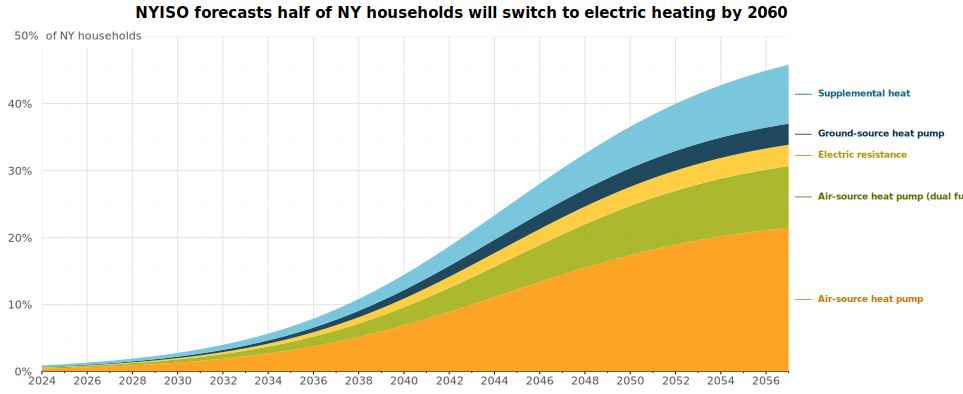

By 2055-56:
  Winter peak (baseline):           50,000 MW
  Summer peak (baseline):           38,430 MW
  Electrification contribution:     21,850 MW
  Initial winter/summer ratio:      77%
BE share of binding peak YoY growth:
  Before crossover (~2038): 6%
  After crossover:                    56%
Headroom exhaustion summary:
shape: (10, 3)
┌─────────────────────────────────┬─────────┬───────────┐
│ facet                           ┆ ex_year ┆ exhausted │
│ ---                             ┆ ---     ┆ ---       │
│ enum                            ┆ i64     ┆ bool      │
╞═════════════════════════════════╪═════════╪═══════════╡
│ National Grid — Baseline        ┆ 2044    ┆ true      │
│ NYSEG & RGE — Baseline          ┆ 2039    ┆ true      │
│ Central Hudson — Baseline       ┆ 2032    ┆ true      │
│ Con Edison — Baseline           ┆ 2034    ┆ true      │
│ Orange & Rockland — Baseline    ┆ 2038    ┆ true      │
│ National Grid — Lower demand    ┆ 2050    ┆ true      │
│ NYSEG & RGE — Lo

In [ ]:
from __future__ import annotations

import subprocess
from pathlib import Path

import numpy as np
import openpyxl
import polars as pl
from plotnine import (
    aes,
    annotate,
    coord_cartesian,
    element_blank,
    facet_grid,
    facet_wrap,
    geom_area,
    geom_col,
    geom_hline,
    geom_line,
    geom_ribbon,
    geom_text,
    geom_vline,
    ggplot,
    guides,
    labs,
    scale_fill_manual,
    scale_x_continuous,
    scale_y_continuous,
    theme,
)
from scipy.optimize import curve_fit

from lib.plotnine import SB_COLORS, theme_switchbox

report_vars: dict = {}

CACHE_DIR = Path("../cache")
CACHE_DIR.mkdir(exist_ok=True)


S3_BASELINE = "s3://data.sb/nyiso/gold_book/2025_baseline_forecast_tables.xlsx"
S3_LOWER = "s3://data.sb/nyiso/gold_book/2025_lower_demand_forecast_tables.xlsx"
S3_HEADROOM = "s3://data.sb/nyiso/gold_book/synapse_headroom_table.csv"

PATH_BASELINE = CACHE_DIR / "gb_2025_baseline.xlsx"
PATH_LOWER = CACHE_DIR / "gb_2025_lower.xlsx"
PATH_HEADROOM = CACHE_DIR / "synapse_headroom_table.csv"

# NYISO load zones A-K
ZONES = ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J", "K"]

# Zone assignments — same lists as rate-design-platform
# `compute_headroom_exhaustion_year.py` (UTILITY_ZONES). National Grid and
# NYSEG & RGE both sum zones A–F; Con Edison includes G+H+I+J; CH and O&R each
# use zone G only (zone G is triple-counted across those three — matches RDP).
UTILITY_ZONES: dict[str, list[str]] = {
    "National Grid": ["A", "B", "C", "D", "E", "F"],
    "NYSEG & RGE": ["A", "B", "C", "D", "E", "F"],
    "Central Hudson": ["G"],
    "Con Edison": ["G", "H", "I", "J"],
    "Orange & Rockland": ["G"],
}

# Synapse adjusted total distribution headroom in MW (Takahashi et al. 2024, Table).
# NYSEG (2,248) + RGE (969) combined for the NYSEG & RGE zone group.
HEADROOM_MW: dict[str, float] = {
    "National Grid": 5892,
    "NYSEG & RGE": 3217,
    "Central Hudson": 258,
    "Con Edison": 2378,
    "Orange & Rockland": 742,
}

# Headroom: absolute I-4b NCP ≥ NCP_base + HEADROOM_MW.
HEADROOM_BASELINE_YEAR = "2023-24"

# Normalization year for stacked ribbons and CP growth line (% of that year’s CP, I-3b).
# Matches rate-design-platform `plot_demand_components_by_utility(..., norm_year="2023-24")`.
NORM_YEAR = "2023-24"

# Forecast horizon (winter season starting year)
FORECAST_START = 2025
FORECAST_END = 2055


def _s3_cp(src: str, dst: Path) -> None:
    """Download a file from S3 to a local path if not already cached."""
    if dst.exists():
        return
    result = subprocess.run(
        ["aws", "s3", "cp", src, str(dst)],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        raise RuntimeError(f"aws s3 cp failed: {result.stderr}")


_s3_cp(S3_BASELINE, PATH_BASELINE)
_s3_cp(S3_LOWER, PATH_LOWER)
_s3_cp(S3_HEADROOM, PATH_HEADROOM)

print(f"Baseline:  {PATH_BASELINE} ({PATH_BASELINE.stat().st_size:,} bytes)")
print(f"Lower:     {PATH_LOWER} ({PATH_LOWER.stat().st_size:,} bytes)")
print(f"Headroom:  {PATH_HEADROOM} ({PATH_HEADROOM.stat().st_size:,} bytes)")


def _parse_winter_str(path: Path, sheet: str) -> dict[str, dict[str, int]]:
    """Parse a Gold Book table with 'YYYY-YY' year column (e.g. I-3b, I-13c)."""
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    ws = wb[sheet]
    data: dict[str, dict[str, int]] = {}
    for row in ws.iter_rows(min_row=7, values_only=True):
        year = row[2]
        if not isinstance(year, str) or "-" not in year:
            continue
        vals = row[3:14]
        if any(v is None for v in vals):
            continue
        data[year] = {z: int(v) for z, v in zip(ZONES, vals, strict=False)}
    wb.close()
    return data


def _parse_calendar_int(path: Path, sheet: str) -> dict[str, dict[str, int]]:
    """Parse a Gold Book table with integer calendar year (e.g. I-3a, I-13b).

    Keys are normalised to 'YYYY-YY' winter season strings so all tables share
    the same key format (calendar year N maps to winter 'N-(N+1)').
    """
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    ws = wb[sheet]
    data: dict[str, dict[str, int]] = {}
    for row in ws.iter_rows(min_row=7, values_only=True):
        year = row[2]
        if not isinstance(year, int):
            continue
        vals = row[3:14]
        if any(v is None for v in vals):
            continue
        key = f"{year}-{(year + 1) % 100:02d}"
        data[key] = {z: int(v) for z, v in zip(ZONES, vals, strict=False)}
    wb.close()
    return data


def _parse_large_loads(path: Path, sheet: str = "I-14") -> dict[str, dict[str, int]]:
    """Parse Table I-14 / I-14-L (Large Loads winter peak, rows start at row 41).

    The Gold Book only forecasts through ~2035-36; values are forward-filled
    through 2056-57 per the Gold Book's own note.
    """
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    ws = wb[sheet]
    data: dict[str, dict[str, int]] = {}
    for row in ws.iter_rows(min_row=41, values_only=True):
        year = row[2]
        if not isinstance(year, str) or "-" not in year:
            continue
        vals = row[3:14]
        if any(v is None for v in vals):
            continue
        data[year] = {z: int(v) for z, v in zip(ZONES, vals, strict=False)}
    wb.close()
    # Forward-fill from the last available row through the forecast horizon
    if data:
        last_year = max(data.keys())
        last_vals = data[last_year]
        for yr in range(int(last_year.split("-")[0]) + 1, FORECAST_END + 2):
            key = f"{yr}-{(yr + 1) % 100:02d}"
            data[key] = last_vals
    return data


def _parse_large_loads_summer(path: Path, sheet: str = "I-14") -> dict[str, dict[str, int]]:
    """Parse I-14 Summer Peak Demand section (rows 29–44, calendar year ints).

    Same forward-fill logic as `_parse_large_loads` for winter.
    """
    wb = openpyxl.load_workbook(path, read_only=True, data_only=True)
    ws = wb[sheet]
    data: dict[str, dict[str, int]] = {}
    for row in ws.iter_rows(min_row=29, max_row=44, values_only=True):
        year = row[2]
        if not isinstance(year, int):
            continue
        vals = row[3:14]
        if any(v is None for v in vals):
            continue
        key = f"{year}-{(year + 1) % 100:02d}"
        data[key] = {z: int(v) for z, v in zip(ZONES, vals, strict=False)}
    wb.close()
    if data:
        last_year = max(data.keys())
        last_vals = data[last_year]
        for yr in range(int(last_year.split("-")[0]) + 1, FORECAST_END + 2):
            key = f"{yr}-{(yr + 1) % 100:02d}"
            data[key] = last_vals
    return data


def _nyca(zone_data: dict[str, dict[str, int]], year: str) -> int:
    """Sum all 11 zones to get the NYCA total for a given year."""
    return sum(zone_data.get(year, {}).get(z, 0) for z in ZONES)


def _util_sum(zone_data: dict[str, dict[str, int]], year: str, zones: list[str]) -> int:
    return sum(zone_data.get(year, {}).get(z, 0) for z in zones)


# Baseline tables
i3b_base = _parse_winter_str(PATH_BASELINE, "I-3b")  # Winter CP (total)
i3a_base = _parse_calendar_int(PATH_BASELINE, "I-3a")  # Summer CP (total)
i4b_base = _parse_winter_str(PATH_BASELINE, "I-4b")  # Winter NCP (non-coincident)
i13c_base = _parse_winter_str(PATH_BASELINE, "I-13c")  # Elec winter CP increment
i13b_base = _parse_calendar_int(PATH_BASELINE, "I-13b")  # Elec summer CP increment
i11d_base = _parse_winter_str(PATH_BASELINE, "I-11d")  # EV winter CP
i8c = _parse_winter_str(PATH_BASELINE, "I-8c")  # EE reductions (same both scenarios)
i10c = _parse_calendar_int(PATH_BASELINE, "I-10c")  # Non-solar DG reductions
i12c = _parse_calendar_int(PATH_BASELINE, "I-12c")  # Storage reductions
i14 = _parse_large_loads(PATH_BASELINE)  # Large loads

# Lower scenario (only EV and electrification differ; shared reductions same as baseline)
i13c_low = _parse_winter_str(PATH_LOWER, "I-13c-L")  # Elec winter CP lower
i11d_low = _parse_winter_str(PATH_LOWER, "I-11d-L")  # EV winter CP lower
i3b_low = _parse_winter_str(PATH_LOWER, "I-3b-L")  # Winter CP lower (total)
i4b_low = _parse_winter_str(PATH_LOWER, "I-4b-L")  # Winter NCP lower
i14_low = _parse_large_loads(PATH_LOWER, sheet="I-14-L")  # Large loads lower

# Summer tables — CP totals and NCP (for Figures 5 and 6)
i3a_low = _parse_calendar_int(PATH_LOWER, "I-3a-L")  # Summer CP lower (total)
i4a_base = _parse_calendar_int(PATH_BASELINE, "I-4a")  # Summer NCP baseline
i4a_low = _parse_calendar_int(PATH_LOWER, "I-4a-L")  # Summer NCP lower

# Summer component tables (for Figure 6)
i13b_low = _parse_calendar_int(PATH_LOWER, "I-13b-L")  # Elec summer CP lower
i11c_base = _parse_calendar_int(PATH_BASELINE, "I-11c")  # EV summer CP
i11c_low = _parse_calendar_int(PATH_LOWER, "I-11c-L")  # EV summer CP lower
i8b = _parse_calendar_int(PATH_BASELINE, "I-8b")  # EE reductions summer
i10b = _parse_calendar_int(PATH_BASELINE, "I-10b")  # Non-solar DG summer
i12b = _parse_calendar_int(PATH_BASELINE, "I-12b")  # Storage summer
i14_summer = _parse_large_loads_summer(PATH_BASELINE)  # Large loads summer
i14_summer_low = _parse_large_loads_summer(PATH_LOWER, sheet="I-14-L")  # Large loads summer lower

# Headroom table from Synapse Energy Economics (Takahashi et al. 2024)
headroom = pl.read_csv(PATH_HEADROOM)

print("Headroom table:")
headroom


all_years = sorted(yr for yr in i13c_base if FORECAST_START <= int(yr.split("-")[0]) <= FORECAST_END)

print(f"Forecast years: {all_years[0]} → {all_years[-1]}  ({len(all_years)} years)")


elec_rows = []
for yr_str in all_years:
    yr = int(yr_str.split("-")[0])
    elec_rows.append(
        {
            "year": yr,
            "mw": _nyca(i13c_base, yr_str),
            "scenario": "Baseline",
        }
    )
    elec_rows.append(
        {
            "year": yr,
            "mw": _nyca(i13c_low, yr_str),
            "scenario": "Lower",
        }
    )

df_elec = pl.DataFrame(elec_rows).sort(["scenario", "year"])

(
    ggplot(df_elec, aes("year", "mw", color="scenario"))
    + geom_line(size=1.3)
    + scale_x_continuous(breaks=list(range(2025, 2056, 5)))
    + scale_y_continuous(labels=lambda lst: [f"{int(v):,}" for v in lst])
    + labs(
        title="NYCA Building Electrification Winter Coincident Peak Demand",
        subtitle=("Cumulative incremental load additions by scenario\nNYISO Gold Book 2025, Table I-13c / I-13c-L"),
        x="Winter season starting year",
        y="MW",
        color="Scenario",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 5.0))
)


last_yr = all_years[-1]
report_vars["elec_winter_mw_baseline_2055"] = _nyca(i13c_base, last_yr)
report_vars["elec_winter_mw_lower_2055"] = _nyca(i13c_low, last_yr)

print(
    f"By {last_yr}, building electrification adds:\n"
    f"  Baseline: {report_vars['elec_winter_mw_baseline_2055']:,} MW\n"
    f"  Lower:    {report_vars['elec_winter_mw_lower_2055']:,} MW"
)


S3_EIA861_BASE = "s3://data.sb/eia/861/electric_utility_stats/"
_AWS_S3_OPTS = {"aws_region": "us-west-2"}

_PATH_CHART_IMAGE = Path("../img/nyiso_nyca_residential_electric_heating_by_technology_reference.jpg")
if not _PATH_CHART_IMAGE.is_file():
    msg = f"Missing reference chart image: {_PATH_CHART_IMAGE.resolve()}"
    raise FileNotFoundError(msg)

# Load raster (JPEG) so the notebook is anchored to this file; re-digitize if replaced.
from matplotlib import image as _mpimg

_ref_img = _mpimg.imread(_PATH_CHART_IMAGE, format="jpeg")
if _ref_img.shape[:2] != (729, 1024):
    msg = "Reference chart image dimensions changed; update cumulative tables above after re-digitizing the new raster."
    raise ValueError(msg)

# Bottom → top stack order (matches legend / NYISO chart).
_TECH_ORDER: list[str] = [
    "Air-source heat pump",
    "Air-source heat pump (dual fuel)",
    "Electric resistance",
    "Ground-source heat pump",
    "Supplemental heat",
]

_TECH_COLORS: dict[str, str] = {
    "Air-source heat pump": SB_COLORS["carrot"],
    "Air-source heat pump (dual fuel)": SB_COLORS["pistachio"],
    "Electric resistance": SB_COLORS["saffron"],
    "Ground-source heat pump": SB_COLORS["midnight"],
    "Supplemental heat": SB_COLORS["sky"],
}

# Cumulative stack tops (housing units) read from the reference image at each knot year.
# Row i = year _DIG_YEARS[i]; columns = upper bound of each band (same definitions as the chart).
_DIG_YEARS = np.array([2024, 2030, 2035, 2040, 2045, 2050, 2055, 2057], dtype=float)
_CUM_TOP_ASHP_FULL = np.array(
    [5_000, 100_000, 250_000, 580_000, 980_000, 1_400_000, 1_650_000, 1_750_000],
    dtype=float,
)
_CUM_TOP_DUAL = np.array(
    [7_000, 140_000, 350_000, 800_000, 1_380_000, 2_000_000, 2_350_000, 2_500_000],
    dtype=float,
)
_CUM_TOP_ER = np.array(
    [8_000, 160_000, 400_000, 900_000, 1_550_000, 2_250_000, 2_600_000, 2_750_000],
    dtype=float,
)
_CUM_TOP_GSHP = np.array(
    [9_000, 180_000, 450_000, 1_000_000, 1_720_000, 2_480_000, 2_850_000, 3_000_000],
    dtype=float,
)
_CUM_TOP_TOTAL = np.array(
    [10_000, 220_000, 550_000, 1_180_000, 2_050_000, 3_000_000, 3_450_000, 3_750_000],
    dtype=float,
)


def _latest_eia861_partition_year() -> int:
    import boto3

    client = boto3.client("s3", region_name=_AWS_S3_OPTS["aws_region"])
    prefix = "eia/861/electric_utility_stats/"
    years: list[int] = []
    paginator = client.get_paginator("list_objects_v2")
    for page in paginator.paginate(Bucket="data.sb", Prefix=prefix, Delimiter="/"):
        for cp in page.get("CommonPrefixes", []):
            name = cp["Prefix"].rstrip("/").split("/")[-1]
            if name.startswith("year="):
                years.append(int(name.split("=", 1)[1]))
    if not years:
        msg = f"No year= partitions under s3://data.sb/{prefix}"
        raise FileNotFoundError(msg)
    return max(years)


def load_ny_residential_electric_customers() -> tuple[float, int]:
    """Statewide sum of residential_customers from EIA-861 parquet on S3."""
    year = _latest_eia861_partition_year()
    path = f"{S3_EIA861_BASE}year={year}/state=NY/data.parquet"
    df = pl.read_parquet(path, storage_options=_AWS_S3_OPTS)
    total = float(df["residential_customers"].sum())
    return total, year


_eia_total, _eia_year = load_ny_residential_electric_customers()

_cum_series = [
    _CUM_TOP_ASHP_FULL,
    _CUM_TOP_DUAL,
    _CUM_TOP_ER,
    _CUM_TOP_GSHP,
    _CUM_TOP_TOTAL,
]
_cum_mat = np.stack(_cum_series, axis=0)  # (5, n_knot): cumulative tops per band
_layer_bottoms = np.vstack([np.zeros((1, _cum_mat.shape[1])), _cum_mat[:-1]])
_layer_thickness_hu = _cum_mat - _layer_bottoms  # housing units per layer at each knot


def _logistic(t: np.ndarray, L: float, k: float, t0: float) -> np.ndarray:
    return L / (1.0 + np.exp(-k * (t - t0)))


def _fit_logistic_layer(years: np.ndarray, fracs: np.ndarray) -> tuple[float, float, float]:
    """Fit logistic to (years, fracs); bounds match `fit_adoption_config._fit_logistic`."""
    L_min = float(fracs.max()) * 1.01
    p0 = [float(fracs.max()) * 1.5, 0.10, 2045.0]
    bounds = ([L_min, 0.001, 2020.0], [1.0, 1.0, 2080.0])
    popt, _ = curve_fit(_logistic, years, fracs, p0=p0, bounds=bounds, maxfev=50_000)
    return float(popt[0]), float(popt[1]), float(popt[2])


_fit_params: list[tuple[float, float, float]] = []
for j, lab in enumerate(_TECH_ORDER):
    fr = _layer_thickness_hu[j] / _eia_total
    par = _fit_logistic_layer(_DIG_YEARS, fr)
    _fit_params.append(par)
    pred = _logistic(_DIG_YEARS, *par)
    rmse = float(np.sqrt(np.mean((pred - fr) ** 2)))
    print(f"{lab}: L,k,t0 = {par}  RMSE(frac)={rmse:.5f}")

_t_fine = np.linspace(2024.0, 2057.0, 400)
_layer_pct: list[np.ndarray] = [100.0 * _logistic(_t_fine, *_fit_params[j]) for j in range(len(_TECH_ORDER))]

_stack_rows: list[dict] = []
for i, yr in enumerate(_t_fine):
    cum_pct = 0.0
    for j, lab in enumerate(_TECH_ORDER):
        top = _layer_pct[j][i]
        lo, hi = cum_pct, cum_pct + top
        _stack_rows.append(
            {
                "year": yr,
                "technology": lab,
                "ymin": lo,
                "ymax": hi,
            }
        )
        cum_pct = hi

_df_stack = pl.DataFrame(_stack_rows).with_columns(
    pl.col("technology").cast(pl.Enum(_TECH_ORDER)),
)

print(
    f"Reference image: {_PATH_CHART_IMAGE.resolve()}\n"
    f"EIA-861 NY residential electric customers: {_eia_total:,.0f} ({_eia_year} data year)"
)

report_vars["eia_ny_residential_customers"] = _eia_total
report_vars["eia_ny_residential_data_year"] = float(_eia_year)
report_vars["nyca_electrified_pct_2057_image_stack"] = float(100.0 * _CUM_TOP_TOTAL[-1] / _eia_total)
report_vars["nyca_electrified_pct_2057_logistic_stack"] = float(
    sum(_logistic(np.array([2057.0]), *_fit_params[j])[0] * 100.0 for j in range(len(_TECH_ORDER)))
)

_TECH_LABEL_COLORS: dict[str, str] = {
    "Air-source heat pump": "#c47600",
    "Air-source heat pump (dual fuel)": SB_COLORS["pistachio_text"],
    "Electric resistance": "#B08E00",
    "Ground-source heat pump": SB_COLORS["midnight"],
    "Supplemental heat": SB_COLORS["midnight_text"],
}

_band_pcts_end = [100.0 * _logistic(np.array([2057.0]), *_fit_params[j])[0] for j in range(len(_TECH_ORDER))]
_label_ys: list[float] = []
_cum_y = 0.0
for j in range(len(_TECH_ORDER)):
    mid = _cum_y + _band_pcts_end[j] / 2
    _label_ys.append(mid)
    _cum_y += _band_pcts_end[j]

from lib.quarto import display_svg

_p = (
    ggplot()
    + geom_ribbon(
        _df_stack,
        aes(x="year", ymin="ymin", ymax="ymax", fill="technology"),
        alpha=0.88,
    )
    + scale_fill_manual(values=_TECH_COLORS)
    + guides(fill=False)
    + scale_x_continuous(
        breaks=list(range(2024, 2058, 2)),
        expand=(0, 0, 0, 0),
    )
    + scale_y_continuous(
        breaks=[0, 10, 20, 30, 40, 50],
        labels=lambda xs: [f"{v:.0f}%" for v in xs],
        limits=(0, 50),
        expand=(0, 0, 0, 0),
    )
    + labs(
        title="NYISO forecasts half of NY households will switch to electric heating by 2060",
        x="",
        y="",
    )
    + theme_switchbox()
    + theme(figure_size=(11.0, 5.5), axis_title_y=element_blank())
)

_fig = _p.draw()
_ax = _fig.axes[0]
_ax.set_xlim(2024, 2057)

_ax.spines["left"].set_visible(False)
for _tick in _ax.yaxis.get_major_ticks():
    _tick.tick1line.set_visible(False)
    _tick.tick2line.set_visible(False)
for _tick in _ax.yaxis.get_minor_ticks():
    _tick.tick1line.set_visible(False)
    _tick.tick2line.set_visible(False)

_ax.tick_params(axis="y", pad=8)

_white_bbox = dict(facecolor="white", edgecolor="none", pad=6)

_fontsize = None
for _label in _ax.yaxis.get_ticklabels():
    if _label.get_text() == "50%":
        _fontsize = _label.get_fontproperties().get_size_in_points()
        _label.set_visible(False)

_ax.text(
    -0.005,
    50.0,
    "50%",
    transform=_ax.get_yaxis_transform(),
    fontsize=_fontsize,
    fontfamily="IBM Plex Sans",
    color="#4D4D4D",
    va="center",
    ha="right",
    clip_on=False,
    zorder=6,
    bbox=_white_bbox,
)
_ax.text(
    0.005,
    50.0,
    " of NY households",
    transform=_ax.get_yaxis_transform(),
    fontsize=_fontsize,
    fontfamily="IBM Plex Sans",
    color="#4D4D4D",
    va="center",
    ha="left",
    clip_on=False,
    zorder=6,
    bbox=_white_bbox,
)

for j, tech in enumerate(_TECH_ORDER):
    _c = _TECH_LABEL_COLORS[tech]
    _y = _label_ys[j]
    _ax.plot([2057.3, 2058.0], [_y, _y], color=_c, linewidth=0.8, clip_on=False)
    _ax.text(
        2058.3,
        _y,
        tech,
        color=_c,
        fontsize=9,
        fontweight="bold",
        va="center",
        ha="left",
        clip_on=False,
        fontfamily="IBM Plex Sans",
    )

_fig.subplots_adjust(right=0.68)
display_svg(_fig)

peak_rows = []
for yr_str in all_years:
    yr = int(yr_str.split("-")[0])
    winter_with = _nyca(i3b_base, yr_str)
    summer_with = _nyca(i3a_base, yr_str)
    be_w = _nyca(i13c_base, yr_str)
    be_s = _nyca(i13b_base, yr_str)

    # Scale BE's gross increment by the fraction that negative sources reduce
    # the overall peak: scale = Peak / (Peak + negatives). This distributes
    # negatives proportionally across all contributors to the peak level
    # (organic load, EVs, large loads, and BE alike).
    neg_w = _nyca(i8c, yr_str) + _nyca(i10c, yr_str) + _nyca(i12c, yr_str)
    scale_w = winter_with / (winter_with + neg_w) if (winter_with + neg_w) > 0 else 1.0

    neg_s = _nyca(i8b, yr_str) + _nyca(i10b, yr_str) + _nyca(i12b, yr_str)
    scale_s = summer_with / (summer_with + neg_s) if (summer_with + neg_s) > 0 else 1.0

    winter_without = winter_with - be_w * scale_w
    summer_without = summer_with - be_s * scale_s
    peak_rows.append(
        {
            "year": yr,
            "winter_with": winter_with,
            "winter_without": winter_without,
            "summer_with": summer_with,
            "summer_without": summer_without,
        }
    )

df_peak = pl.DataFrame(peak_rows)

# Initial winter-to-summer ratio annotation
first = df_peak.row(0, named=True)
ratio_pct = f"{first['winter_with'] / first['summer_with']:.0%}"
mid_y = (first["winter_with"] + first["summer_with"]) / 2

_y_hi = max(df_peak["winter_with"].max(), df_peak["summer_with"].max()) * 1.05

(
    ggplot()
    # Winter ribbon (electrification contribution)
    + geom_ribbon(
        df_peak,
        aes(x="year", ymin="winter_without", ymax="winter_with"),
        fill=SB_COLORS["sky"],
        alpha=0.25,
    )
    # Summer ribbon
    + geom_ribbon(
        df_peak,
        aes(x="year", ymin="summer_without", ymax="summer_with"),
        fill=SB_COLORS["carrot"],
        alpha=0.25,
    )
    # Solid lines — with electrification
    + geom_line(
        df_peak,
        aes(x="year", y="winter_with"),
        color=SB_COLORS["sky"],
        size=1.3,
    )
    + geom_line(
        df_peak,
        aes(x="year", y="summer_with"),
        color=SB_COLORS["carrot"],
        size=1.3,
    )
    # Dashed lines — without electrification
    + geom_line(
        df_peak,
        aes(x="year", y="winter_without"),
        color=SB_COLORS["sky"],
        size=1.0,
        linetype="dashed",
    )
    + geom_line(
        df_peak,
        aes(x="year", y="summer_without"),
        color=SB_COLORS["carrot"],
        size=1.0,
        linetype="dashed",
    )
    # Bracket and ratio annotation
    + annotate(
        "segment",
        x=2025,
        xend=2025,
        y=first["winter_with"],
        yend=first["summer_with"],
        color="#555555",
        size=0.7,
    )
    + annotate(
        "text",
        x=2025.6,
        y=mid_y,
        label=ratio_pct,
        size=11,
        ha="left",
        color="#333333",
    )
    + scale_x_continuous(
        breaks=list(range(2025, 2056, 5)),
        expand=(0, 0),
    )
    + scale_y_continuous(
        labels=lambda lst: [f"{int(v):,}" if v > 0 else "" for v in lst],
        expand=(0, 0),
    )
    + coord_cartesian(xlim=(2025, 2055), ylim=(0, _y_hi))
    + labs(
        title="NYCA Coincident Peak Demand Forecast — Baseline Scenario",
        subtitle=(
            "Solid = with building electrification; dashed = without; ribbon = electrification contribution\n"
            "Source: NYISO Gold Book 2025, Tables I-3a, I-3b, I-13b, I-13c"
        ),
        x="Year",
        y="Net peak (MW)",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 5.5))
)


last_yr = all_years[-1]
report_vars["winter_peak_baseline_2055"] = _nyca(i3b_base, last_yr)
report_vars["summer_peak_baseline_2055"] = _nyca(i3a_base, last_yr)
report_vars["elec_contribution_winter_2055"] = _nyca(i13c_base, last_yr)
report_vars["winter_summer_ratio_2025"] = _nyca(i3b_base, all_years[0]) / _nyca(i3a_base, all_years[0])

print(
    f"By {last_yr}:\n"
    f"  Winter peak (baseline):           {report_vars['winter_peak_baseline_2055']:,} MW\n"
    f"  Summer peak (baseline):           {report_vars['summer_peak_baseline_2055']:,} MW\n"
    f"  Electrification contribution:     {report_vars['elec_contribution_winter_2055']:,} MW\n"
    f"  Initial winter/summer ratio:      {report_vars['winter_summer_ratio_2025']:.0%}"
)

summer_base_peak = _nyca(i3a_base, all_years[0])

slice_rows = []
for yr_str in all_years:
    yr = int(yr_str.split("-")[0])
    peak = _nyca(i3a_base, yr_str)
    net_growth = peak - summer_base_peak

    be_gross = _nyca(i13b_base, yr_str)
    ev_gross = _nyca(i11c_base, yr_str)
    ll_gross = _nyca(i14_summer, yr_str)
    neg = _nyca(i8b, yr_str) + _nyca(i10b, yr_str) + _nyca(i12b, yr_str)

    # Organic growth = net growth minus what the identified drivers explain.
    # Gross positive growth = net growth + negatives (add back what negatives took).
    organic_gross = net_growth - (be_gross + ev_gross + ll_gross) + neg
    gross_pos = net_growth + neg  # = organic_gross + be_gross + ev_gross + ll_gross

    # Scale each gross positive driver down so they sum to net growth.
    scale = net_growth / gross_pos if gross_pos > 0 else 0.0

    for component, mw in [
        ("Base (2025 level)", summer_base_peak),
        ("Organic growth", max(organic_gross * scale, 0)),
        ("Building electrification", be_gross * scale),
        ("EV load", ev_gross * scale),
        ("Large loads", ll_gross * scale),
    ]:
        slice_rows.append({"year": yr, "component": component, "mw": mw})

df_slices = pl.DataFrame(slice_rows)

# Stack order: base at bottom, then organic, BE, EV, large loads on top.
# geom_area draws first Enum level on top, so reverse the desired bottom-to-top.
_stack_order = pl.Enum(
    [
        "Building electrification",
        "EV load",
        "Large loads",
        "Organic growth",
        "Base (2025 level)",
    ]
)
df_slices = df_slices.with_columns(pl.col("component").cast(_stack_order))

_slice_colors = {
    "Base (2025 level)": "#e0e0e0",
    "Organic growth": "#999999",
    "Large loads": SB_COLORS["sky"],
    "EV load": SB_COLORS["carrot"],
    "Building electrification": SB_COLORS["saffron"],
}

(
    ggplot(df_slices, aes(x="year", y="mw", fill="component"))
    + geom_area(alpha=0.85)
    + scale_fill_manual(values=_slice_colors, name="")
    + scale_x_continuous(
        breaks=list(range(2025, 2056, 5)),
        expand=(0, 0),
    )
    + scale_y_continuous(
        labels=lambda lst: [f"{int(v):,}" if v > 0 else "" for v in lst],
        expand=(0, 0),
    )
    + coord_cartesian(
        xlim=(2025, 2055),
        ylim=(0, max(df_peak["summer_with"].max(), df_peak["winter_with"].max()) * 1.05),
    )
    + labs(
        title="Summer Coincident Peak — Growth Decomposition (Baseline)",
        subtitle=(
            "Each growth driver scaled down proportionally by negative sources (EE, DG, storage)\n"
            "Source: NYISO Gold Book 2025"
        ),
        x="Year",
        y="Net peak (MW)",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 5.5))
)

winter_base_peak = _nyca(i3b_base, all_years[0])

# Build separate DataFrames for summer and winter
summer_rows = []
winter_rows = []
for yr_str in all_years:
    yr = int(yr_str.split("-")[0])

    # --- Summer ---
    s_peak = _nyca(i3a_base, yr_str)
    s_growth = s_peak - summer_base_peak
    s_be = _nyca(i13b_base, yr_str)
    s_ev = _nyca(i11c_base, yr_str)
    s_ll = _nyca(i14_summer, yr_str)
    s_neg = _nyca(i8b, yr_str) + _nyca(i10b, yr_str) + _nyca(i12b, yr_str)
    s_organic_gross = s_growth - (s_be + s_ev + s_ll) + s_neg
    s_gross_pos = s_growth + s_neg
    s_scale = s_growth / s_gross_pos if s_gross_pos > 0 else 0.0

    for comp, mw in [
        ("S: base", summer_base_peak),
        ("S: organic", max(s_organic_gross * s_scale, 0)),
        ("S: large loads", s_ll * s_scale),
        ("S: EV load", s_ev * s_scale),
        ("S: BE", s_be * s_scale),
    ]:
        summer_rows.append({"year": yr, "component": comp, "mw": mw})

    # --- Winter ---
    w_peak = _nyca(i3b_base, yr_str)
    w_growth = w_peak - winter_base_peak
    w_be = _nyca(i13c_base, yr_str)
    w_ev = _nyca(i11d_base, yr_str)
    w_ll = _nyca(i14, yr_str)
    w_neg = _nyca(i8c, yr_str) + _nyca(i10c, yr_str) + _nyca(i12c, yr_str)
    w_organic_gross = w_growth - (w_be + w_ev + w_ll) + w_neg
    w_gross_pos = w_growth + w_neg
    w_scale = w_growth / w_gross_pos if w_gross_pos > 0 else 0.0

    for comp, mw in [
        ("Base (2025 level)", winter_base_peak),
        ("Organic growth", max(w_organic_gross * w_scale, 0)),
        ("Large loads", w_ll * w_scale),
        ("EV load", w_ev * w_scale),
        ("Building electrification", w_be * w_scale),
    ]:
        winter_rows.append({"year": yr, "component": comp, "mw": mw})

_s_order = pl.Enum(["S: BE", "S: EV load", "S: large loads", "S: organic", "S: base"])
_w_order = pl.Enum(
    [
        "Building electrification",
        "EV load",
        "Large loads",
        "Organic growth",
        "Base (2025 level)",
    ]
)

df_summer = pl.DataFrame(summer_rows).with_columns(pl.col("component").cast(_s_order))
df_winter = pl.DataFrame(winter_rows).with_columns(pl.col("component").cast(_w_order))

# Summer: lighter versions of the same palette as a background reference
_s_colors = {
    "S: base": "#ececec",
    "S: organic": "#bfbfbf",
    "S: large loads": "#a8d8e8",
    "S: EV load": "#fdd88a",
    "S: BE": "#ffe4a0",
}
# Winter: same colors as the summer decomposition chart
_w_colors = {
    "Base (2025 level)": "#e0e0e0",
    "Organic growth": "#999999",
    "Large loads": SB_COLORS["sky"],
    "EV load": SB_COLORS["carrot"],
    "Building electrification": SB_COLORS["saffron"],
}

# Interpolate the exact fractional year where winter crosses summer
_diff = df_peak.with_columns((pl.col("winter_with") - pl.col("summer_with")).alias("gap"))
_cross_idx = _diff.with_columns((pl.col("gap") >= 0).alias("crossed")).filter(pl.col("crossed"))["year"].min()
_pre = _diff.filter(pl.col("year") == _cross_idx - 1).row(0, named=True)
_post = _diff.filter(pl.col("year") == _cross_idx).row(0, named=True)
_frac = -_pre["gap"] / (_post["gap"] - _pre["gap"]) if _post["gap"] != _pre["gap"] else 0
_cross_year = _pre["year"] + _frac
_cross_summer = _pre["summer_with"] + _frac * (_post["summer_with"] - _pre["summer_with"])

_summer_line_df = pl.concat(
    [
        pl.DataFrame({"year": [_cross_year], "summer_with": [_cross_summer]}),
        df_peak.filter((pl.col("winter_with") >= pl.col("summer_with")) & (pl.col("year") > _cross_idx))
        .select("year", "summer_with")
        .cast({"year": pl.Float64, "summer_with": pl.Float64}),
    ]
)

_y_max = max(df_peak["summer_with"].max(), df_peak["winter_with"].max()) * 1.05

(
    ggplot()
    # Summer behind — faded background reference, hidden from legend
    + geom_area(df_summer, aes(x="year", y="mw", fill="component"), alpha=0.7, show_legend=False)
    # Winter on top — full opacity so summer doesn't show through
    + geom_area(df_winter, aes(x="year", y="mw", fill="component"), alpha=1.0)
    # Vertical line at the interpolated crossover year
    + geom_vline(xintercept=_cross_year, color=SB_COLORS["pistachio"], size=0.3, linetype="solid")
    # Summer peak outline — from interpolated crossover point onward
    + geom_line(
        _summer_line_df,
        aes(x="year", y="summer_with"),
        color="#999999",
        size=0.5,
        linetype="dotted",
    )
    + scale_fill_manual(
        values={**_s_colors, **_w_colors},
        limits=list(_w_colors.keys()),
        name="",
    )
    + scale_x_continuous(
        breaks=list(range(2025, 2056, 5)),
        expand=(0, 0),
    )
    + scale_y_continuous(
        labels=lambda lst: [f"{int(v):,}" if v > 0 else "" for v in lst],
        expand=(0, 0),
    )
    + coord_cartesian(xlim=(2025, 2055), ylim=(0, _y_max))
    + labs(
        title="Summer + Winter Coincident Peak — Growth Decomposition (Baseline)",
        subtitle=(
            "Summer (warm tones, behind) and winter (cool tones, in front), both from zero\n"
            "Source: NYISO Gold Book 2025"
        ),
        x="Year",
        y="Net peak (MW)",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 6.5))
)


yoy_rows = []
prev_binding = None

for i, yr_str in enumerate(all_years):
    yr = int(yr_str.split("-")[0])

    # Summer decomposition
    s_peak = _nyca(i3a_base, yr_str)
    s_growth = s_peak - summer_base_peak
    s_be = _nyca(i13b_base, yr_str)
    s_ev = _nyca(i11c_base, yr_str)
    s_ll = _nyca(i14_summer, yr_str)
    s_neg = _nyca(i8b, yr_str) + _nyca(i10b, yr_str) + _nyca(i12b, yr_str)
    s_gross_pos = s_growth + s_neg
    s_scale = s_growth / s_gross_pos if s_gross_pos > 0 else 0.0

    # Winter decomposition
    w_peak = _nyca(i3b_base, yr_str)
    w_growth = w_peak - winter_base_peak
    w_be = _nyca(i13c_base, yr_str)
    w_ev = _nyca(i11d_base, yr_str)
    w_ll = _nyca(i14, yr_str)
    w_neg = _nyca(i8c, yr_str) + _nyca(i10c, yr_str) + _nyca(i12c, yr_str)
    w_gross_pos = w_growth + w_neg
    w_scale = w_growth / w_gross_pos if w_gross_pos > 0 else 0.0

    if w_peak >= s_peak:
        binding = w_peak
        be_cum = w_be * w_scale
        ev_cum = w_ev * w_scale
        ll_cum = w_ll * w_scale
        org_cum = max((w_growth - (w_be + w_ev + w_ll) + w_neg) * w_scale, 0)
    else:
        binding = s_peak
        be_cum = s_be * s_scale
        ev_cum = s_ev * s_scale
        ll_cum = s_ll * s_scale
        org_cum = max((s_growth - (s_be + s_ev + s_ll) + s_neg) * s_scale, 0)

    if prev_binding is not None:
        delta = binding - prev_binding
        above_base = be_cum + ev_cum + ll_cum + org_cum
        if above_base > 0 and delta > 0:
            share_be = be_cum / above_base
            share_ev = ev_cum / above_base
            share_ll = ll_cum / above_base
            share_org = org_cum / above_base
        else:
            share_be = share_ev = share_ll = share_org = 0.25

        for comp, mw in [
            ("Building electrification", delta * share_be),
            ("EV load", delta * share_ev),
            ("Large loads", delta * share_ll),
            ("Organic growth", delta * share_org),
        ]:
            yoy_rows.append({"year": yr, "component": comp, "mw": mw})

    prev_binding = binding

df_yoy = pl.DataFrame(yoy_rows)

_yoy_order = pl.Enum(
    [
        "Building electrification",
        "EV load",
        "Large loads",
        "Organic growth",
    ]
)
df_yoy = df_yoy.with_columns(pl.col("component").cast(_yoy_order))

_yoy_colors = {
    "Building electrification": SB_COLORS["saffron"],
    "EV load": SB_COLORS["carrot"],
    "Large loads": SB_COLORS["sky"],
    "Organic growth": "#999999",
}

(
    ggplot(df_yoy, aes(x="year", y="mw", fill="component"))
    + geom_col(alpha=0.9)
    + geom_vline(xintercept=_cross_year, color=SB_COLORS["pistachio"], size=0.7, linetype="dashed")
    + scale_fill_manual(values=_yoy_colors, name="")
    + scale_x_continuous(
        breaks=list(range(2025, 2056, 5)),
        expand=(0, 0.5),
    )
    + scale_y_continuous(
        labels=lambda lst: [f"{int(v):,}" for v in lst],
    )
    + labs(
        title="Annual Increase in Binding Peak — Who Drives Capacity Costs?",
        subtitle=(
            "Before the green line: summer is binding (BE is small). After: winter is binding (BE dominates).\n"
            "Source: NYISO Gold Book 2025, Baseline scenario"
        ),
        x="Year",
        y="Year-over-year Δ peak (MW)",
    )
    + theme_switchbox()
    + theme(figure_size=(10.5, 5.5))
)


_cross_yr_int = int(_cross_year)
_pre_cross = df_yoy.filter(pl.col("year") <= _cross_yr_int)
_post_cross = df_yoy.filter(pl.col("year") > _cross_yr_int)


def _be_share_yoy(df: pl.DataFrame) -> float:
    total = df["mw"].sum()
    be = df.filter(pl.col("component") == "Building electrification")["mw"].sum()
    return be / total if total > 0 else 0.0


report_vars["be_share_binding_pre_cross"] = _be_share_yoy(_pre_cross)
report_vars["be_share_binding_post_cross"] = _be_share_yoy(_post_cross)

print(
    f"BE share of binding peak YoY growth:\n"
    f"  Before crossover (~{_cross_yr_int}): {report_vars['be_share_binding_pre_cross']:.0%}\n"
    f"  After crossover:                    {report_vars['be_share_binding_post_cross']:.0%}"
)


COMPONENT_COLORS: dict[str, str] = {
    "Base (2025 level)": "#e0e0e0",
    "Organic growth": "#999999",
    "EV load": SB_COLORS["carrot"],
    "Building electrification": SB_COLORS["saffron"],
    "Large loads": "#e8f4f8",
}


# Per-scenario CP tables and component tables
SCENARIOS: dict[str, dict] = {
    "Baseline": {
        "i3b": i3b_base,
        "i4b": i4b_base,
        "pos": [
            ("Building electrification", i13c_base),
            ("EV load", i11d_base),
            ("Large loads", i14),
        ],
        "neg": [
            ("EE & codes/standards", i8c),
            ("Non-solar DG", i10c),
            ("BTM storage", i12c),
        ],
    },
    "Lower demand": {
        "i3b": i3b_low,
        "i4b": i4b_low,
        "pos": [
            ("Building electrification", i13c_low),
            ("EV load", i11d_low),
            ("Large loads", i14_low),
        ],
        "neg": [
            # EE, DG, storage not separately published for lower scenario;
            # reuse baseline (conservative — lower scenario reductions likely larger)
            ("EE & codes/standards", i8c),
            ("Non-solar DG", i10c),
            ("BTM storage", i12c),
        ],
    },
}

component_order = [
    "Large loads",
    "Building electrification",
    "EV load",
    "Organic growth",
    "Base (2025 level)",
]

# Build stacked ribbon data and CP growth lines for both scenarios
stack_rows = []
growth_rows = []
headroom_rows = []

for scenario, sc in SCENARIOS.items():
    # Same horizon logic as RDP: scan I-4b rows from 2024-25 onward (keys present in
    # this scenario’s file — lower-demand I-4b-L may omit 2024-25).
    headroom_years = sorted(
        yr for yr in sc["i4b"] if int(yr.split("-")[0]) >= 2024 and int(yr.split("-")[0]) <= FORECAST_END
    )

    for utility, zones in UTILITY_ZONES.items():
        base_cp = _util_sum(i3b_base, NORM_YEAR, zones)
        if base_cp == 0:
            continue

        # NCP excluding large loads vs threshold (Synapse headroom MW).
        # Large loads connect at substations, not feeders.
        ncp_base = _util_sum(i4b_base, HEADROOM_BASELINE_YEAR, zones)
        ll_base = _util_sum(i14 if scenario == "Baseline" else i14_low, HEADROOM_BASELINE_YEAR, zones)
        threshold = (ncp_base - ll_base) + HEADROOM_MW[utility]
        ex_yr: int | None = None
        for yr_str in headroom_years:
            ncp = _util_sum(sc["i4b"], yr_str, zones)
            ll = _util_sum(i14 if scenario == "Baseline" else i14_low, yr_str, zones)
            if (ncp - ll) >= threshold:
                ex_yr = int(yr_str.split("-")[0])
                break

        label = (
            f"Headroom\nexhausted\n{ex_yr}–{ex_yr - 1999:02d}"
            if ex_yr is not None
            else "Not exhausted\nwithin forecast"
        )

        headroom_rows.append(
            {
                "scenario": scenario,
                "utility": utility,
                "ex_year": ex_yr if ex_yr is not None else -1,
                "exhausted": ex_yr is not None,
                "label": label,
            }
        )

        for yr_str in all_years:
            yr = int(yr_str.split("-")[0])

            cp_val = _util_sum(sc["i3b"], yr_str, zones)
            net_growth = cp_val - base_cp
            net_growth_pct = 100.0 * net_growth / base_cp

            # Gross positive and negative totals (in MW)
            pos_mw = {lab: _util_sum(data, yr_str, zones) for lab, data in sc["pos"]}
            neg_mw_total = sum(_util_sum(data, yr_str, zones) for _, data in sc["neg"])

            # Organic growth = net growth - (identified positives - negatives)
            identified_pos_total = sum(pos_mw.values())
            organic_gross = net_growth - identified_pos_total + neg_mw_total
            gross_pos_total = net_growth + neg_mw_total

            scale = net_growth / gross_pos_total if gross_pos_total > 0 else 0.0

            # Stack order: organic, large loads, EV, BE (matching NYCA charts)
            pos_bottom = 0.0
            organic_pct = 100.0 * max(organic_gross * scale, 0) / base_cp
            stack_rows.append(
                {
                    "scenario": scenario,
                    "utility": utility,
                    "year": yr,
                    "component": "Organic growth",
                    "ymin": pos_bottom,
                    "ymax": pos_bottom + organic_pct,
                }
            )
            pos_bottom += organic_pct

            for comp_label in ["Large loads", "EV load", "Building electrification"]:
                pct = 100.0 * pos_mw[comp_label] * scale / base_cp
                stack_rows.append(
                    {
                        "scenario": scenario,
                        "utility": utility,
                        "year": yr,
                        "component": comp_label,
                        "ymin": pos_bottom,
                        "ymax": pos_bottom + pct,
                    }
                )
                pos_bottom += pct

            growth_rows.append(
                {
                    "scenario": scenario,
                    "utility": utility,
                    "year": yr,
                    "cp_growth_pct": net_growth_pct,
                }
            )

df_stack = pl.DataFrame(stack_rows).with_columns(
    pl.col("component").cast(pl.Enum(component_order)),
    pl.col("scenario").cast(pl.Enum(["Baseline", "Lower demand"])),
)
df_growth = pl.DataFrame(growth_rows).with_columns(
    pl.col("scenario").cast(pl.Enum(["Baseline", "Lower demand"])),
)
df_headroom = pl.DataFrame(headroom_rows)

# Facet label: "Utility — Scenario"
df_stack = df_stack.with_columns((pl.col("utility") + " — " + pl.col("scenario")).alias("facet"))
df_growth = df_growth.with_columns((pl.col("utility") + " — " + pl.col("scenario")).alias("facet"))
df_headroom = df_headroom.with_columns((pl.col("utility") + " — " + pl.col("scenario")).alias("facet"))

# Natural facet order: utility order × scenario order
facet_order = [f"{u} — {s}" for u in UTILITY_ZONES for s in ["Baseline", "Lower demand"]]
df_stack = df_stack.with_columns(pl.col("facet").cast(pl.Enum(facet_order)))
df_growth = df_growth.with_columns(pl.col("facet").cast(pl.Enum(facet_order)))
df_headroom = df_headroom.with_columns(pl.col("facet").cast(pl.Enum(facet_order)))

print("Headroom exhaustion summary:")
print(df_headroom.select(["facet", "ex_year", "exhausted"]))


# Plotnine refuses saves > 25 in by default; this figure is 24×34 in.
from plotnine.options import set_option

set_option("limitsize", False)

# Vlines for exhausted utilities
df_vline = df_headroom.filter(pl.col("exhausted"))

# For the "not exhausted" text label, we need a y position near the top of each
# panel. Use a fixed high percentage since panels have free_y scales.
# We'll annotate using geom_text at x=2055 (right edge), placed per-facet.
df_not_exhausted = df_headroom.filter(~pl.col("exhausted"))

# y position for exhaustion label: place just below the max ymax of the ribbon
# for each facet. Compute per-facet max of positive stack top.
_pos_tops = df_stack.filter(pl.col("ymax") > 0).group_by("facet").agg(pl.col("ymax").max().alias("top"))
df_vline = df_vline.join(_pos_tops, on="facet", how="left")
df_not_exhausted = df_not_exhausted.join(_pos_tops, on="facet", how="left")

(
    ggplot()
    + geom_ribbon(
        df_stack,
        aes(x="year", ymin="ymin", ymax="ymax", fill="component"),
        alpha=0.85,
    )
    + geom_hline(yintercept=0, color="black", size=0.6)
    + geom_line(
        df_growth,
        aes(x="year", y="cp_growth_pct"),
        color="black",
        size=1.2,
        linetype="solid",
    )
    + geom_vline(
        df_vline,
        aes(xintercept="ex_year"),
        color="#cc2222",
        size=1.0,
        linetype="dashed",
    )
    + geom_text(
        df_vline,
        aes(x="ex_year", y="top", label="label"),
        color="#cc2222",
        size=8,
        ha="left",
        va="top",
        nudge_x=0.4,
    )
    + geom_text(
        df_not_exhausted,
        aes(x=2055, y="top", label="label"),
        color="#cc2222",
        size=8,
        ha="right",
        va="top",
    )
    + facet_grid("utility ~ scenario", scales="free_y")
    + scale_fill_manual(
        values=COMPONENT_COLORS,
        name="Component",
        breaks=component_order,
    )
    + scale_x_continuous(breaks=list(range(2025, 2056, 5)))
    + scale_y_continuous(
        labels=lambda lst: [f"{v:.0f}%" for v in lst],
    )
    + labs(
        title="Winter Coincident Peak Demand Components by Utility — Baseline vs. Lower Demand",
        subtitle=(
            "As % of 2023-24 coincident winter peak (I-3b) — NYISO Gold Book 2025\n"
            "Black line = total CP growth; red dashed = headroom exhaustion (Synapse 2024)"
        ),
        x="Winter season starting year",
        y="% of 2023–24 peak",
    )
    + theme_switchbox()
    + theme(figure_size=(24, 34))
)


season_growth_rows: list[dict] = []

SEASON_TABLES: dict[str, dict[str, dict]] = {
    "Baseline": {"winter": i3b_base, "summer": i3a_base},
    "Lower demand": {"winter": i3b_low, "summer": i3a_low},
}

for scenario, tables in SEASON_TABLES.items():
    for utility, zones in UTILITY_ZONES.items():
        base_cp = _util_sum(i3a_base, NORM_YEAR, zones)
        if base_cp == 0:
            continue

        for yr_str in all_years:
            yr = int(yr_str.split("-")[0])
            for season_name, cp_table in tables.items():
                cp_val = _util_sum(cp_table, yr_str, zones)
                season_growth_rows.append(
                    {
                        "scenario": scenario,
                        "utility": utility,
                        "year": yr,
                        "season": season_name.capitalize(),
                        "cp_growth_pct": 100.0 * (cp_val - base_cp) / base_cp,
                    }
                )

df_season_growth = pl.DataFrame(season_growth_rows).with_columns(
    pl.col("season").cast(pl.Enum(["Winter", "Summer"])),
    pl.col("scenario").cast(pl.Enum(["Baseline", "Lower demand"])),
)
df_season_growth = df_season_growth.with_columns((pl.col("utility") + " — " + pl.col("scenario")).alias("facet"))
df_season_growth = df_season_growth.with_columns(pl.col("facet").cast(pl.Enum(facet_order)))

# Find the crossover year where winter CP first exceeds summer CP (in absolute MW).
# Both are normalized to the same summer base, so winter > summer iff
# winter_growth_pct > summer_growth_pct.
crossover_rows: list[dict] = []
for scenario, tables in SEASON_TABLES.items():
    for utility, zones in UTILITY_ZONES.items():
        facet_label = f"{utility} — {scenario}"
        prev_diff: float | None = None
        prev_yr: int | None = None
        for yr_str in all_years:
            yr = int(yr_str.split("-")[0])
            w_val = _util_sum(tables["winter"], yr_str, zones)
            s_val = _util_sum(tables["summer"], yr_str, zones)
            diff = float(w_val - s_val)
            if diff >= 0:
                # Interpolate between previous year (winter < summer) and this year
                if prev_diff is not None and prev_yr is not None and prev_diff < 0:
                    frac = -prev_diff / (diff - prev_diff)
                    cross_x = prev_yr + frac
                else:
                    cross_x = float(yr)
                cross_yr_int = round(cross_x)
                crossover_rows.append(
                    {
                        "facet": facet_label,
                        "cross_year": cross_x,
                        "label": f"Winter ≥ summer\n~{cross_yr_int}–{cross_yr_int - 1999:02d}",
                    }
                )
                break
            prev_diff = diff
            prev_yr = yr

df_crossover = pl.DataFrame(crossover_rows)
if not df_crossover.is_empty():
    df_crossover = df_crossover.with_columns(pl.col("facet").cast(pl.Enum(facet_order)))

print("Season growth data shape:", df_season_growth.shape)
print(df_season_growth.head(6))
print("\nCrossover years:")
print(df_crossover)


# Build winter peak decomposition as stacked ribbons (same growth-based scaling
# as Figure 4), plus summer peak as a single line, both in absolute MW.
_winter_slice_rows: list[dict] = []
_summer_line_rows: list[dict] = []

_WINTER_SCENARIOS: dict[str, dict] = {
    "Baseline": {
        "i3b": i3b_base,
        "pos": [
            ("Building electrification", i13c_base),
            ("EV load", i11d_base),
            ("Large loads", i14),
        ],
        "neg": [i8c, i10c, i12c],
    },
    "Lower demand": {
        "i3b": i3b_low,
        "pos": [
            ("Building electrification", i13c_low),
            ("EV load", i11d_low),
            ("Large loads", i14_low),
        ],
        "neg": [i8c, i10c, i12c],
    },
}

for scenario, sc in _WINTER_SCENARIOS.items():
    for utility, zones in UTILITY_ZONES.items():
        summer_base_cp = _util_sum(i3a_base, NORM_YEAR, zones)
        winter_base_cp = _util_sum(sc["i3b"], all_years[0], zones)
        if summer_base_cp == 0:
            continue

        for yr_str in all_years:
            yr = int(yr_str.split("-")[0])

            w_peak = _util_sum(sc["i3b"], yr_str, zones)
            w_growth = w_peak - winter_base_cp

            pos_mw = {lab: _util_sum(data, yr_str, zones) for lab, data in sc["pos"]}
            neg_total = sum(_util_sum(d, yr_str, zones) for d in sc["neg"])
            identified_pos = sum(pos_mw.values())
            organic_gross = w_growth - identified_pos + neg_total
            gross_pos = w_growth + neg_total
            scale = w_growth / gross_pos if gross_pos > 0 else 0.0

            # Stack order (bottom to top): base, organic, EV, BE, large loads
            # Large loads go on top (faded) because they connect at substations,
            # not feeders, and don't drive distribution investment.
            _winter_slice_rows.append(
                {
                    "scenario": scenario,
                    "utility": utility,
                    "year": yr,
                    "component": "Base (2025 level)",
                    "ymin": 0.0,
                    "ymax": float(winter_base_cp),
                }
            )

            bottom = float(winter_base_cp)

            org_mw = max(organic_gross * scale, 0)
            _winter_slice_rows.append(
                {
                    "scenario": scenario,
                    "utility": utility,
                    "year": yr,
                    "component": "Organic growth",
                    "ymin": bottom,
                    "ymax": bottom + org_mw,
                }
            )
            bottom += org_mw

            for comp_label in ["EV load", "Building electrification"]:
                mw = pos_mw[comp_label] * scale
                _winter_slice_rows.append(
                    {
                        "scenario": scenario,
                        "utility": utility,
                        "year": yr,
                        "component": comp_label,
                        "ymin": bottom,
                        "ymax": bottom + mw,
                    }
                )
                bottom += mw

            # Track distribution-relevant winter peak (excluding large loads)
            _dist_winter = bottom

            ll_mw = pos_mw["Large loads"] * scale
            _winter_slice_rows.append(
                {
                    "scenario": scenario,
                    "utility": utility,
                    "year": yr,
                    "component": "Large loads",
                    "ymin": bottom,
                    "ymax": bottom + ll_mw,
                }
            )

            # Summer line
            s_val = _util_sum(
                i3a_base if scenario == "Baseline" else i3a_low,
                yr_str,
                zones,
            )
            _summer_line_rows.append(
                {
                    "scenario": scenario,
                    "utility": utility,
                    "year": yr,
                    "summer_mw": float(s_val),
                    "dist_winter_mw": _dist_winter,
                }
            )

df_w_slices = pl.DataFrame(_winter_slice_rows).with_columns(
    pl.col("component").cast(pl.Enum(component_order)),
    pl.col("scenario").cast(pl.Enum(["Baseline", "Lower demand"])),
)
df_w_slices = df_w_slices.with_columns((pl.col("utility") + " — " + pl.col("scenario")).alias("facet")).with_columns(
    pl.col("facet").cast(pl.Enum(facet_order))
)

df_summer_line = pl.DataFrame(_summer_line_rows).with_columns(
    pl.col("scenario").cast(pl.Enum(["Baseline", "Lower demand"])),
)
df_summer_line = df_summer_line.with_columns(
    (pl.col("utility") + " — " + pl.col("scenario")).alias("facet")
).with_columns(pl.col("facet").cast(pl.Enum(facet_order)))

# Distribution crossover: where dist_winter (excl. large loads) >= summer
dist_cross_rows: list[dict] = []
for scenario in ["Baseline", "Lower demand"]:
    for utility in UTILITY_ZONES:
        _df = df_summer_line.filter((pl.col("scenario") == scenario) & (pl.col("utility") == utility)).sort("year")
        prev_diff: float | None = None
        prev_yr: int | None = None
        for row in _df.iter_rows(named=True):
            diff = row["dist_winter_mw"] - row["summer_mw"]
            if diff >= 0:
                if prev_diff is not None and prev_yr is not None and prev_diff < 0:
                    frac = -prev_diff / (diff - prev_diff)
                    cross_x = prev_yr + frac
                else:
                    cross_x = float(row["year"])
                cross_yr_int = round(cross_x)
                dist_cross_rows.append(
                    {
                        "utility": utility,
                        "scenario": scenario,
                        "cross_year": cross_x,
                        "label": f"Dist. winter ≥ summer\n~{cross_yr_int}–{cross_yr_int - 1999:02d}",
                    }
                )
                break
            prev_diff = diff
            prev_yr = row["year"]

df_dist_crossover = pl.DataFrame(dist_cross_rows)

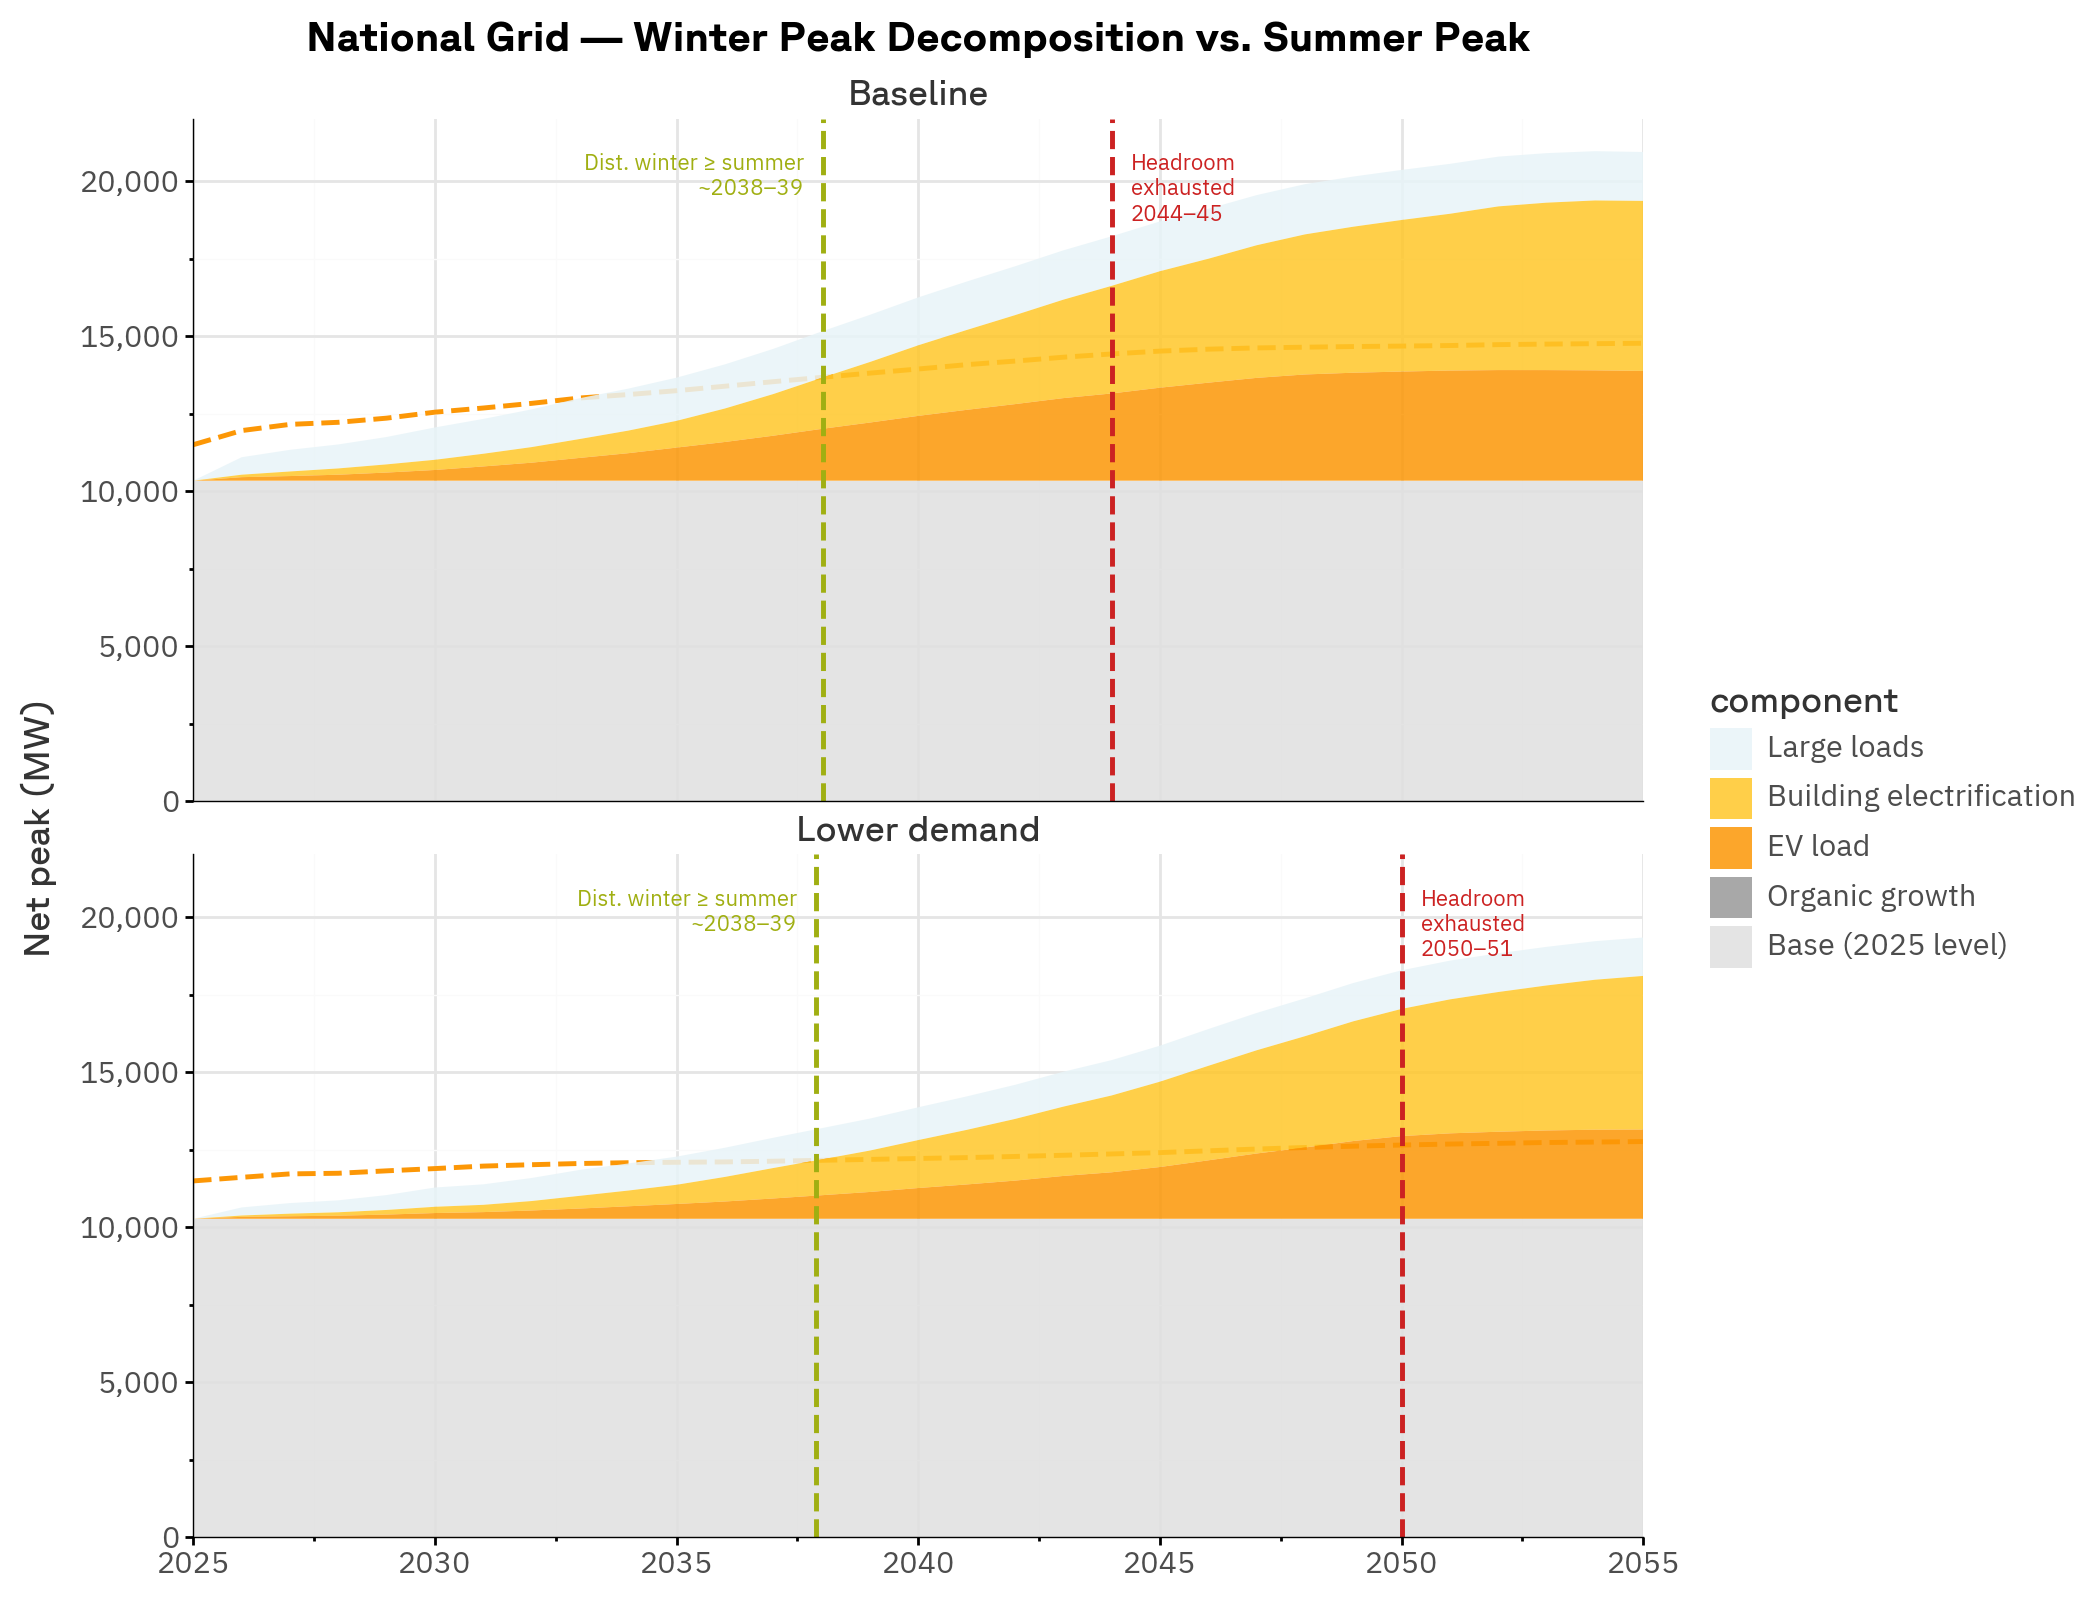

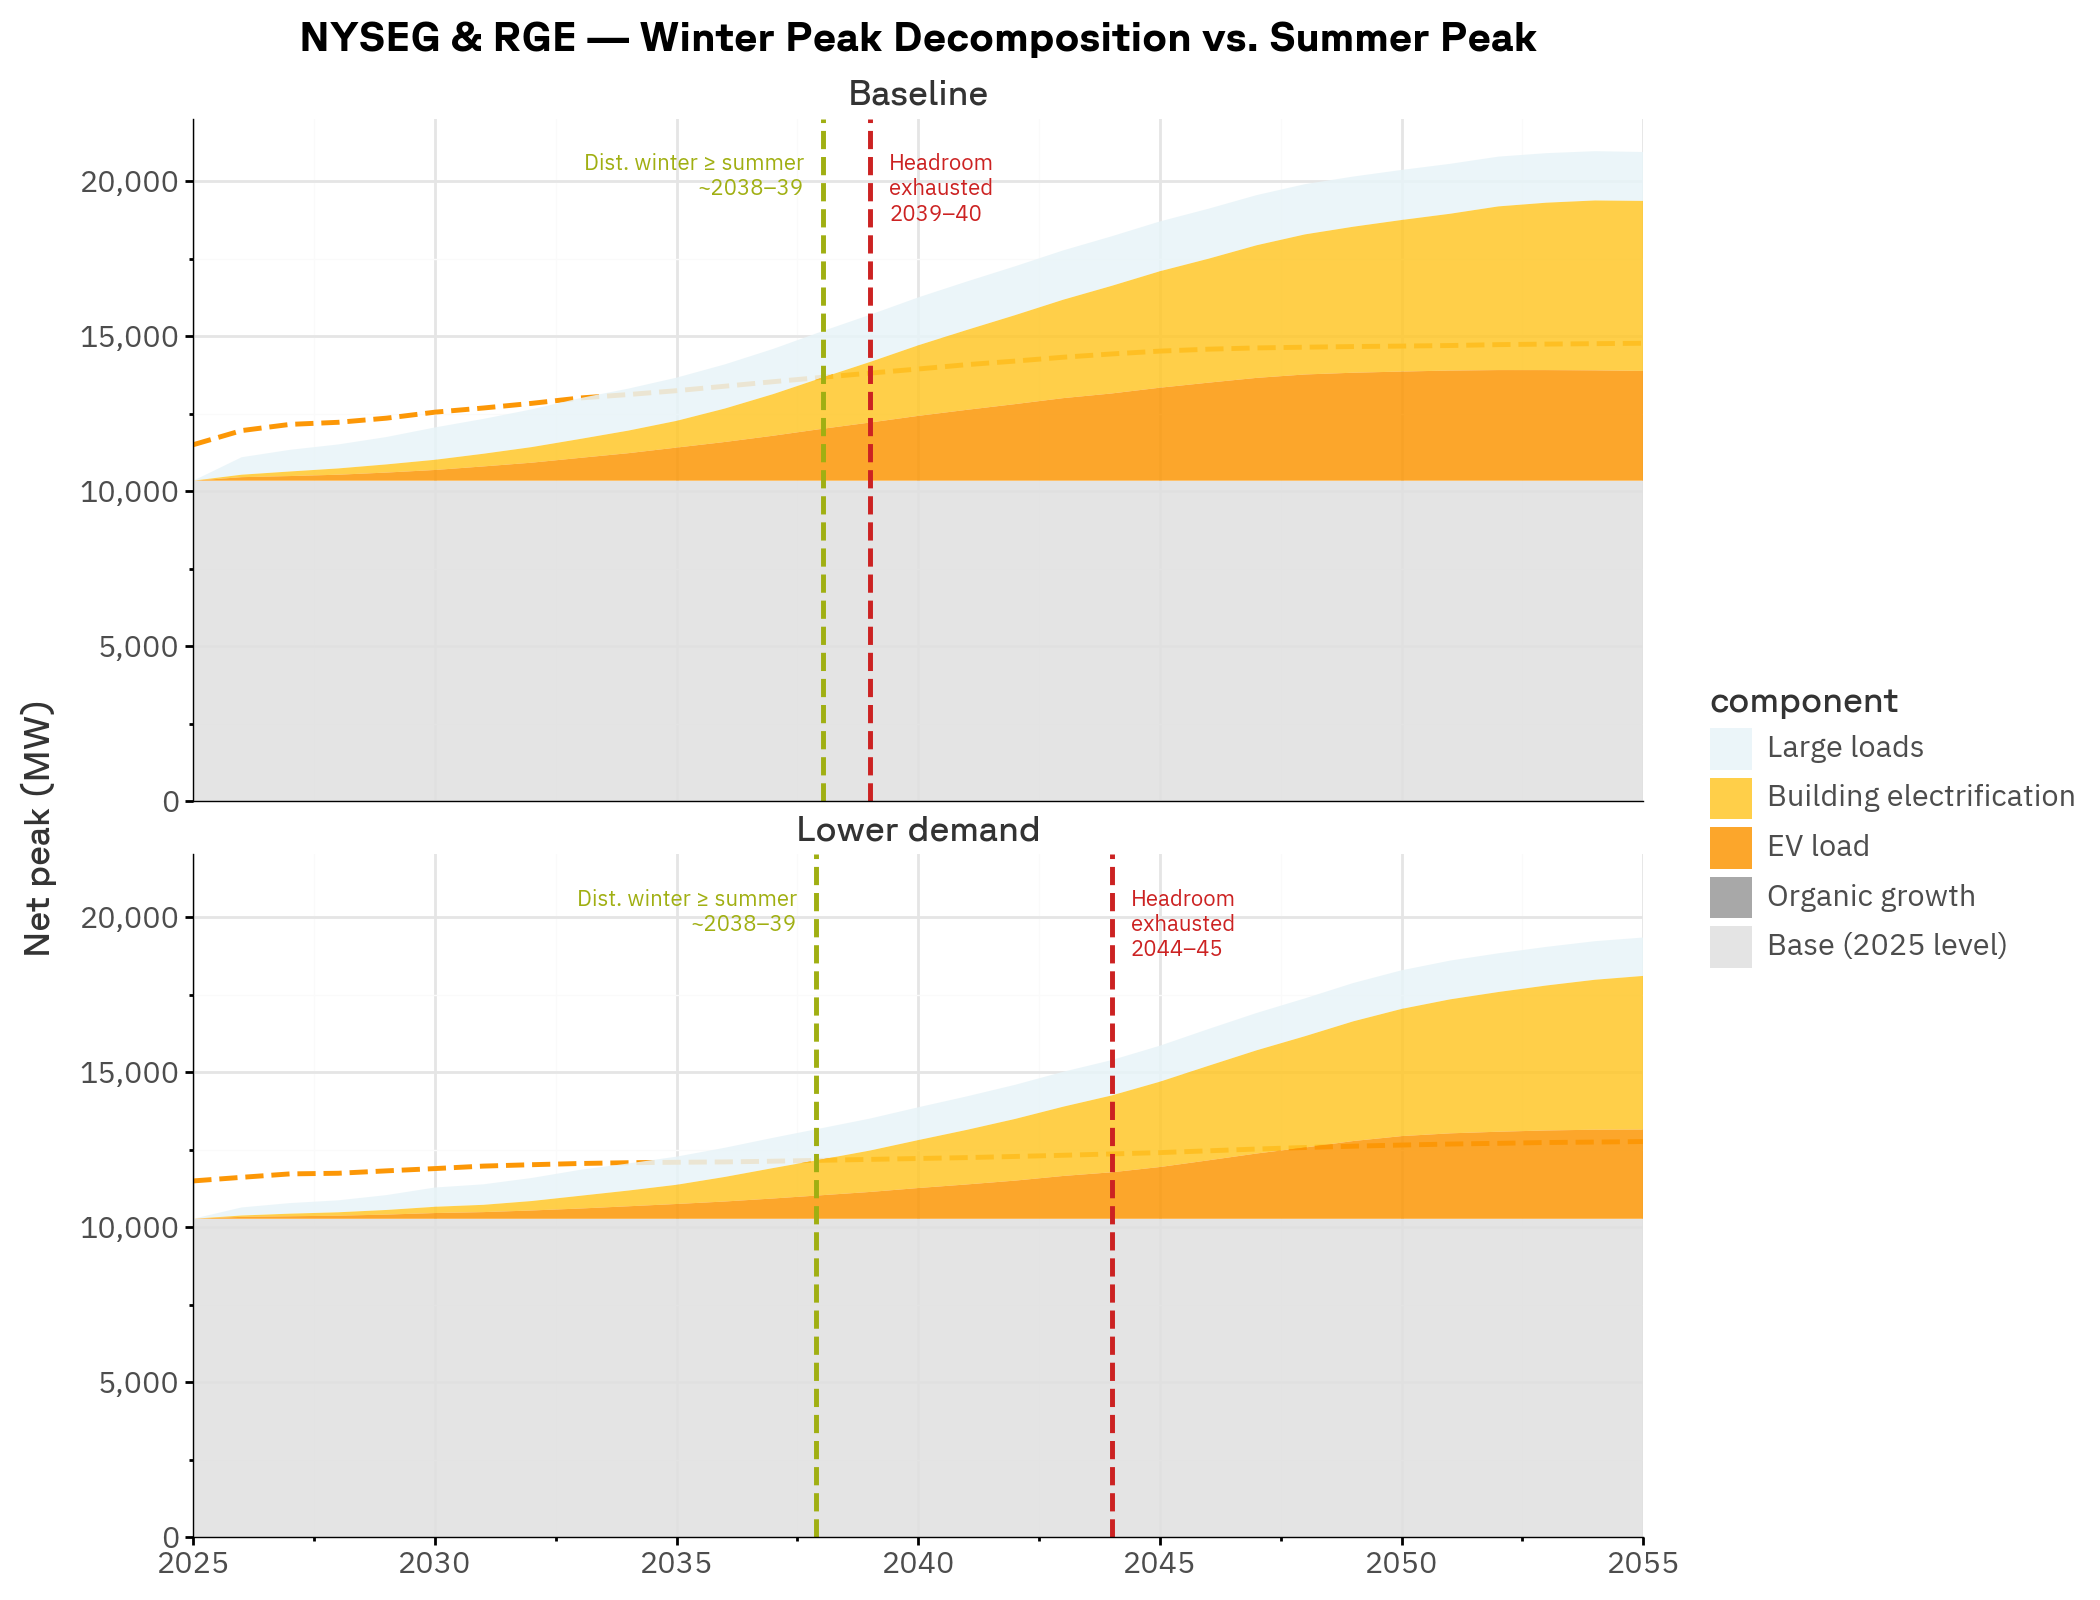

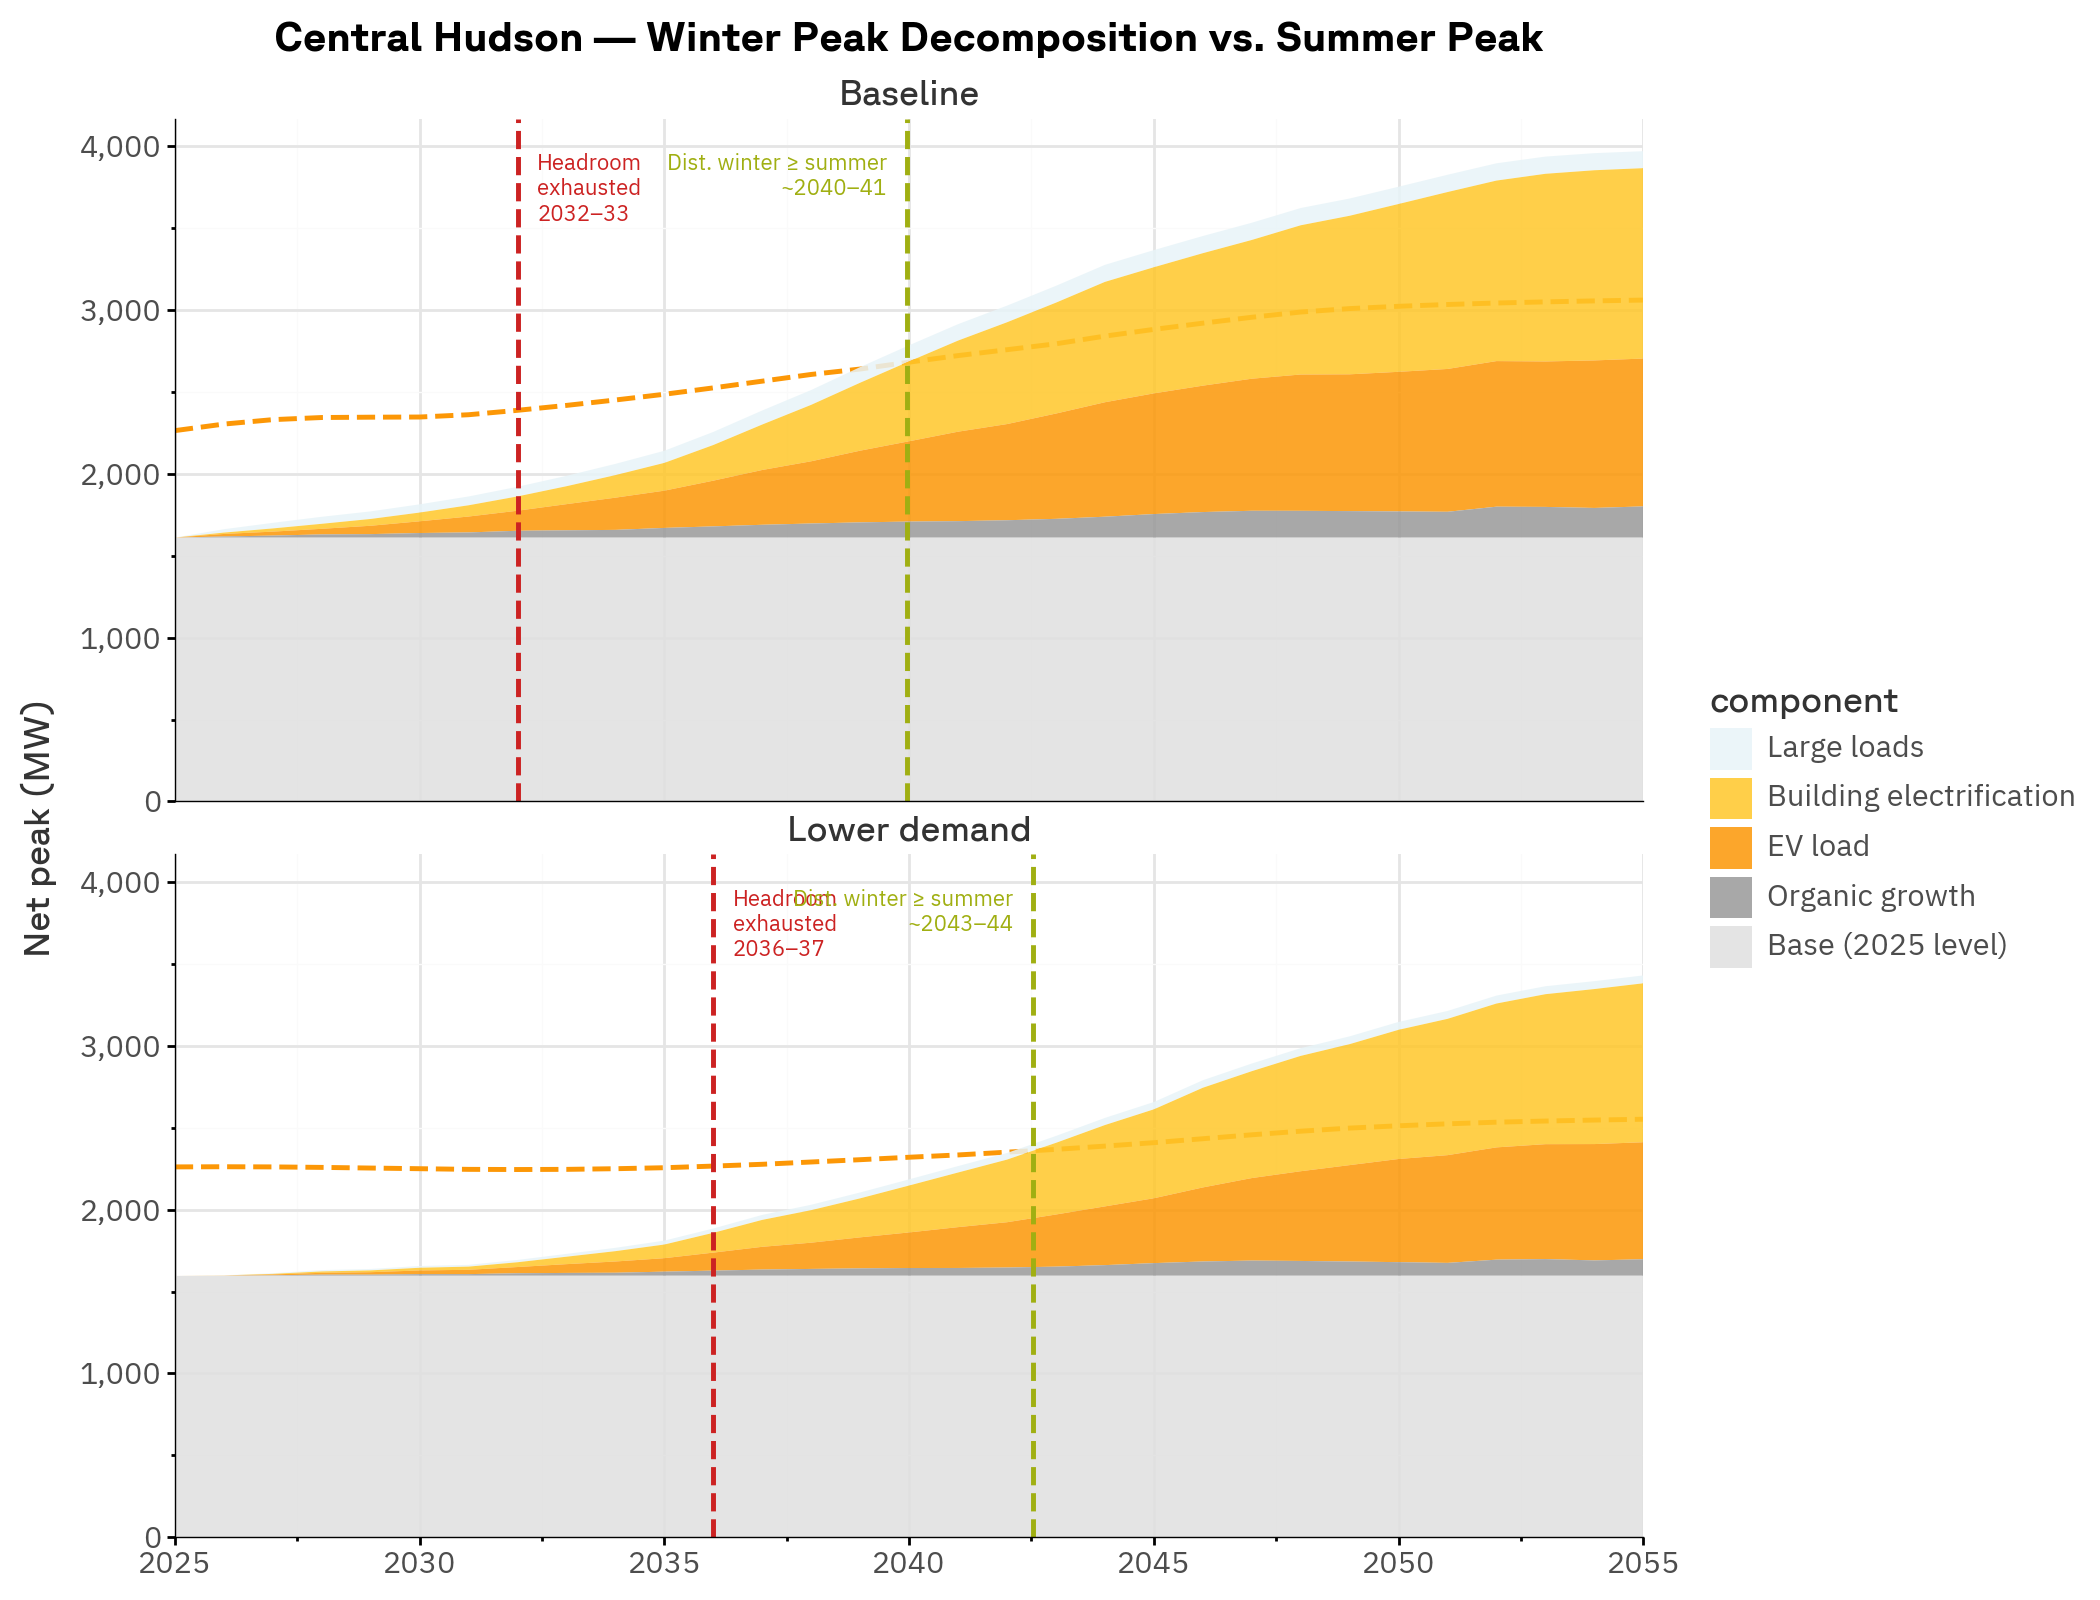

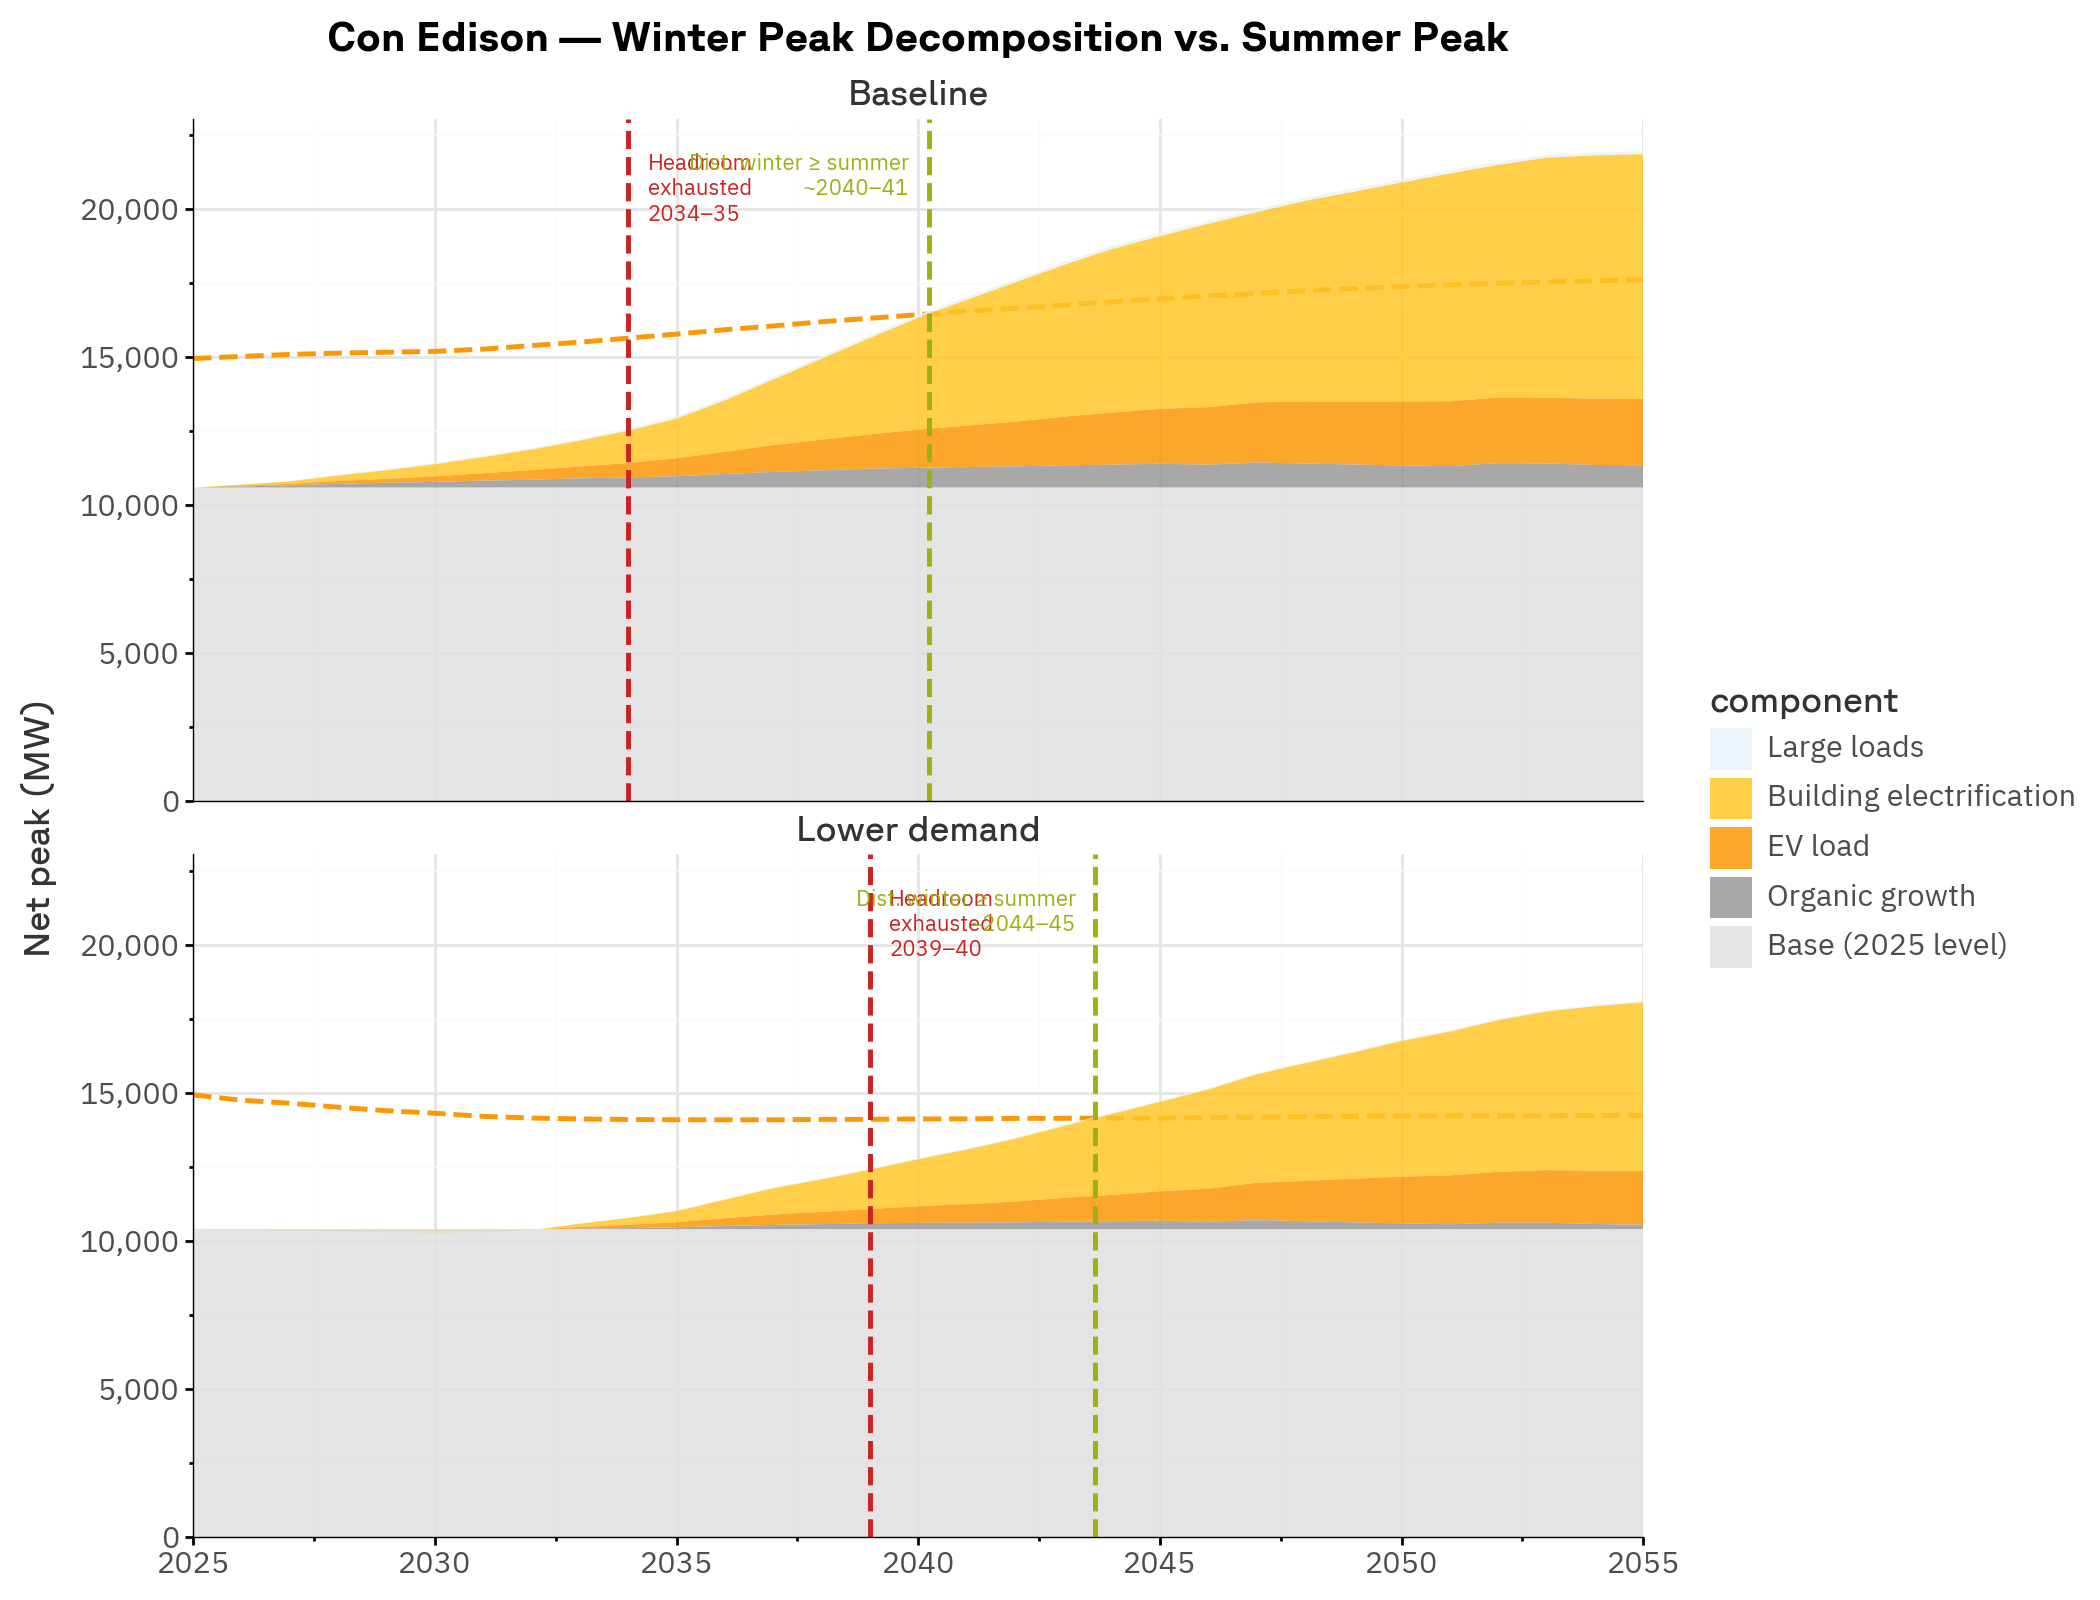

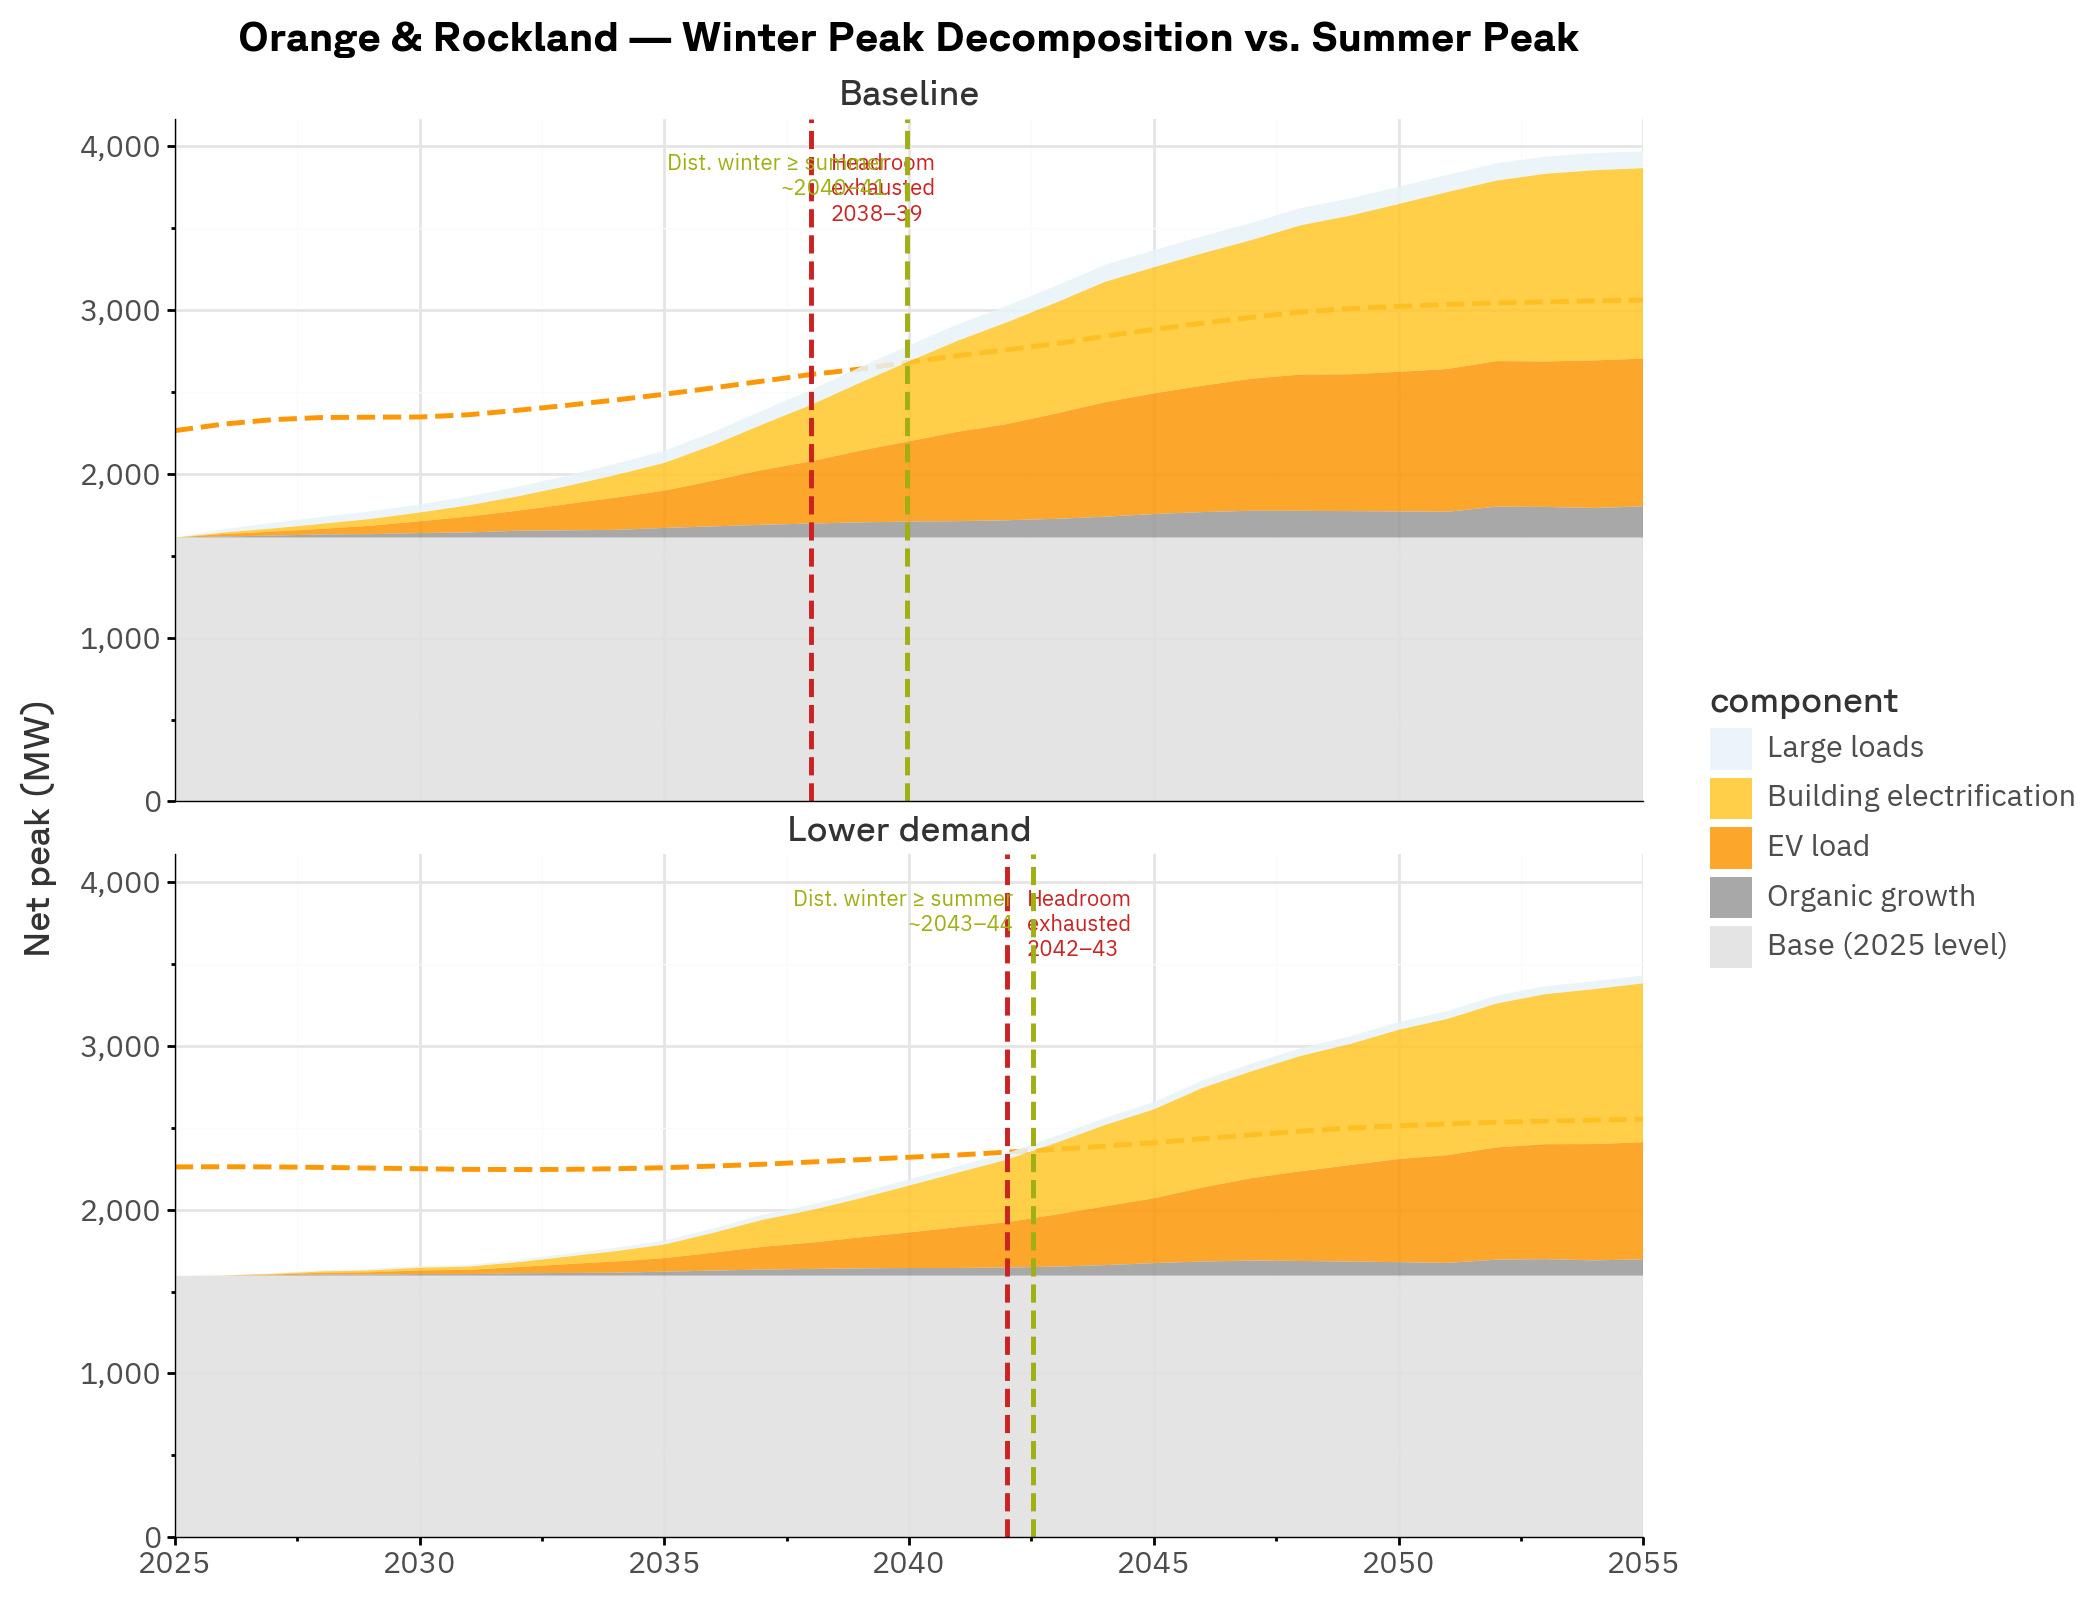

In [ ]:
from plotnine.options import set_option

set_option("limitsize", False)

_df_hr_vline = df_headroom.filter(pl.col("exhausted"))
_df_hr_no = df_headroom.filter(~pl.col("exhausted"))

_season_tops = df_w_slices.group_by("facet").agg(pl.col("ymax").max().alias("top"))
_df_hr_vline = _df_hr_vline.join(_season_tops, on="facet", how="left")
_df_hr_no = _df_hr_no.join(_season_tops, on="facet", how="left")
_df_cross_labeled = (
    df_crossover.join(_season_tops, on="facet", how="left") if not df_crossover.is_empty() else df_crossover
)

for _util in UTILITY_ZONES:
    _u_slices = df_w_slices.filter(pl.col("utility") == _util)
    _u_summer = df_summer_line.filter(pl.col("utility") == _util)
    _u_y_max = max(_u_slices["ymax"].max(), _u_summer["summer_mw"].max()) * 1.05

    _u_hr = _df_hr_vline.filter(pl.col("utility") == _util)
    _u_hr_no = _df_hr_no.filter(pl.col("utility") == _util)

    # Distribution crossover: where winter (excl. large loads) >= summer
    _u_cross = (
        df_dist_crossover.filter(pl.col("utility") == _util) if not df_dist_crossover.is_empty() else df_dist_crossover
    )

    if not _u_hr.is_empty():
        _u_hr = _u_hr.with_columns(pl.lit(_u_y_max * 0.95).alias("top"))
    if not _u_hr_no.is_empty():
        _u_hr_no = _u_hr_no.with_columns(pl.lit(_u_y_max * 0.95).alias("top"))
    if not _u_cross.is_empty():
        _u_cross = _u_cross.with_columns(pl.lit(_u_y_max * 0.95).alias("top"))

    _p = (
        ggplot()
        + geom_line(
            _u_summer,
            aes(x="year", y="summer_mw"),
            color=SB_COLORS["carrot"],
            size=1.0,
            linetype="dashed",
        )
        + geom_ribbon(
            _u_slices,
            aes(x="year", ymin="ymin", ymax="ymax", fill="component"),
            alpha=0.85,
        )
    )
    if not _u_hr.is_empty():
        _p = (
            _p
            + geom_vline(
                _u_hr,
                aes(xintercept="ex_year"),
                color="#cc2222",
                size=1.0,
                linetype="dashed",
            )
            + geom_text(
                _u_hr,
                aes(x="ex_year", y="top", label="label"),
                color="#cc2222",
                size=8,
                ha="left",
                va="top",
                nudge_x=0.4,
            )
        )
    if not _u_hr_no.is_empty():
        _p = _p + geom_text(
            _u_hr_no,
            aes(x=2055, y="top", label="label"),
            color="#cc2222",
            size=8,
            ha="right",
            va="top",
        )
    if not _u_cross.is_empty():
        _p = (
            _p
            + geom_vline(
                _u_cross,
                aes(xintercept="cross_year"),
                color=SB_COLORS["pistachio"],
                size=1.0,
                linetype="dashed",
            )
            + geom_text(
                _u_cross,
                aes(x="cross_year", y="top", label="label"),
                color=SB_COLORS["pistachio"],
                size=8,
                ha="right",
                va="top",
                nudge_x=-0.4,
            )
        )

    _p = (
        _p
        + facet_wrap("scenario", ncol=1)
        + scale_fill_manual(values=COMPONENT_COLORS, name="")
        + scale_x_continuous(breaks=list(range(2025, 2056, 5)), expand=(0, 0))
        + scale_y_continuous(
            labels=lambda lst: [f"{int(v):,}" for v in lst],
            expand=(0, 0),
        )
        + coord_cartesian(xlim=(2025, 2055), ylim=(0, _u_y_max))
        + labs(
            title=f"{_util} — Winter Peak Decomposition vs. Summer Peak",
            x="",
            y="Net peak (MW)",
        )
        + theme_switchbox()
        + theme(figure_size=(10.5, 8))
    )
    from IPython.display import display

    display(_p)

No kernel connected